In [17]:
!pip install \
fastapi \
"uvicorn[standard]" \
pandas \
numpy \
scipy \
prophet \
cmdstanpy \
holidays \
joblib \
scikit-learn \
statsmodels \
openpyxl \
python-multipart \
matplotlib \
seaborn \
plotly \
python-dotenv \
pydantic-settings


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import glob
import os
import json
import pickle
from prophet.serialize import model_to_json, model_from_json
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import warnings
import time
import sys
from datetime import datetime, timedelta
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 22
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

In [19]:
print("TAHAP 1: SETUP DIREKTORI DAN INTEGRASI DATABASE FISIK")
print("-" * 80)
nama_folder = '../datasets'
folder_visual = '../visualizations'
folder_models = '../models'

if not os.path.exists(nama_folder):
    os.makedirs(nama_folder)
    print(f"Direktori '{nama_folder}' berhasil diinisialisasi.")

if not os.path.exists(folder_visual):
    os.makedirs(folder_visual)
    print(f"Direktori '{folder_visual}' berhasil diinisialisasi.")

if not os.path.exists(folder_models):
    os.makedirs(folder_models)
    print(f"Direktori '{folder_models}' berhasil diinisialisasi.")

file_pattern = os.path.join(nama_folder, "**/*.xlsx")
list_file = glob.glob(file_pattern, recursive=True)

# Filter out temporary files or reports that might be in the same folder
list_file = [f for f in list_file if not os.path.basename(f).startswith('~$') and 'LAPORAN_EKSEKUTIF' not in f]

if len(list_file) == 0:
    print("!"*80)
    print("WARNING: TIDAK ADA DATASET FISIK. MEMULAI GENERASI DATA SINTETIK 4 TAHUN.")
    print("Sistem akan menciptakan 1460 hari data transaksi laundry realistis.")
    print("!"*80)
    
    tgl_start = datetime(2022, 1, 1)
    koleksi_transaksi = []
    
    list_layanan = ['Cuci Kering', 'Cuci Setrika', 'Express 4 Jam', 'Cuci Karpet', 'Cuci Sepatu', 'Cuci Helm', 'Boneka Jumbo', 'Gorden', 'Selimut']
    list_admin = ['Ahmad', 'Siti', 'Budi', 'Lani', 'Joko', 'Dewi', 'Rian', 'Maya']
    list_metode = ['Cash', 'QRIS', 'Transfer Bank', 'ShopeePay', 'Gopay']
    
    dict_harga = {
        'Cuci Kering': 7000, 'Cuci Setrika': 9000, 'Express 4 Jam': 18000, 
        'Cuci Karpet': 35000, 'Cuci Sepatu': 25000, 'Cuci Helm': 20000, 
        'Boneka Jumbo': 40000, 'Gorden': 15000, 'Selimut': 25000
    }
    
    for d in range(1460):
        tgl_skrg = tgl_start + timedelta(days=d)
        
        # Simulasi Faktor Eksternal (Seasonality & Trend)
        val_base = 50
        val_weekend = 40 if tgl_skrg.weekday() >= 5 else 0
        val_payday = 25 if (25 <= tgl_skrg.day <= 30) else 0
        val_eid = 80 if (tgl_skrg.month == 4 and 10 <= tgl_skrg.day <= 25) else 0
        val_rainy = 20 if (tgl_skrg.month in [1, 2, 11, 12]) else 0
        val_growth = d / 15
        
        # Variansi Acak (Noise)
        val_noise = np.random.normal(0, 15)
        
        # Total Order Harian
        vol_harian = int(val_base + val_weekend + val_payday + val_eid + val_rainy + val_growth + val_noise)
        vol_harian = max(25, vol_harian)
        
        for idx in range(vol_harian):
            layanan_pilih = np.random.choice(list_layanan, p=[0.35, 0.25, 0.1, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05])
            berat_pilih = round(np.random.uniform(1.0, 25.0), 2)
            if layanan_pilih in ['Cuci Karpet', 'Cuci Sepatu', 'Cuci Helm', 'Boneka Jumbo']:
                berat_pilih = np.random.randint(1, 6)
            
            total_bayar = berat_pilih * dict_harga[layanan_pilih]
            
            koleksi_transaksi.append({
                'No. Transaksi': f'TRX-{tgl_skrg.strftime("%Y%m%d")}-{idx:03d}',
                'Tanggal': tgl_skrg,
                'Jam_Masuk': f'{np.random.randint(7, 22):02d}:{np.random.choice([0, 15, 30, 45]):02d}',
                'Customer_ID': f'CUST-{np.random.randint(100, 5000)}',
                'Layanan': layanan_pilih,
                'Berat/Satuan': berat_pilih,
                'Harga Unit': dict_harga[layanan_pilih],
                'Total Bayar': total_bayar,
                'Metode_Pembayaran': np.random.choice(list_metode),
                'Admin': np.random.choice(list_admin),
                'Status_Pengerjaan': 'Selesai'
            })
    
    df_simulasi = pd.DataFrame(koleksi_transaksi)
    path_excel = os.path.join(nama_folder, 'MASTER_DATA_3Y_NEW.xlsx')
    df_simulasi.to_excel(path_excel, sheet_name='Laporan Rekap Transaksi', index=False)
    print(f"Data Master Berhasil Diciptakan: {path_excel}")
    print(f"Volume Data: {len(df_simulasi)} baris transaksi.")
    list_file = [path_excel]

TAHAP 1: SETUP DIREKTORI DAN INTEGRASI DATABASE FISIK
--------------------------------------------------------------------------------


In [20]:
print("\nTAHAP 2: INGESTI DATA DAN KONSOLIDASI TABEL")
print("-" * 80)
buffer_frames = []
target_sheet = "Laporan Transaksi laundry"

for p in sorted(list_file):
    print(f"Mengkonsumsi berkas: {os.path.basename(p)}...", end=" ")
    try:
        # Menggunakan header=1 karena baris pertama di Excel adalah judul/header tabel yang sesungguhnya
        df_temp = pd.read_excel(p, sheet_name=target_sheet, header=1)
        
        # Mapping kolom dari dataset asli ke skema internal script
        mapping_kolom = {
            'Kode Trx': 'No. Transaksi',
            'Tgl. Trx': 'Tanggal',
            'Jasa': 'Layanan',
            'Harga': 'Harga Unit',
            'Grandtotal': 'Total Bayar',
            'Admin': 'Admin',
            'Pelanggan': 'Customer_ID',
            'Tunai': 'Bayar_Tunai',
            'Non-Tunai': 'Bayar_NonTunai',
            'EDC': 'Bayar_EDC',
            'Saldo': 'Bayar_Saldo',
            'Subtotal': 'Subtotal',
            'Discount': 'Diskon',
            'Ongkir': 'Ongkos_Kirim',
            'Koin': 'Penggunaan_Koin'
        }
        
        # Rename kolom yang tersedia
        df_temp = df_temp.rename(columns=mapping_kolom)
        
        # Klasifikasi Metode Pembayaran Utama berdasarkan nominal terbesar
        def hitung_metode(row):
            vals = {
                'Cash': row.get('Bayar_Tunai', 0),
                'Transfer/Digital': row.get('Bayar_NonTunai', 0),
                'Kartu (EDC)': row.get('Bayar_EDC', 0),
                'Potong Saldo': row.get('Bayar_Saldo', 0)
            }
            # Ambil key dengan value tertinggi, default 'Lainnya' jika semua nol
            max_key = max(vals, key=vals.get)
            if vals[max_key] > 0:
                return max_key
            return 'Lainnya'

        df_temp['Metode_Utama'] = df_temp.apply(hitung_metode, axis=1)
        
        # Penanganan khusus untuk Berat/Satuan (Mengambil Kiloan jika ada, jika tidak ambil Satuan)
        if 'Kiloan' in df_temp.columns and 'Satuan' in df_temp.columns:
            df_temp['Berat/Satuan'] = df_temp['Kiloan'].fillna(df_temp['Satuan'])
        elif 'Kiloan' in df_temp.columns:
            df_temp['Berat/Satuan'] = df_temp['Kiloan']
        elif 'Satuan' in df_temp.columns:
            df_temp['Berat/Satuan'] = df_temp['Satuan']
        else:
            df_temp['Berat/Satuan'] = 1.0 # Default fallback
            
        buffer_frames.append(df_temp)
        print("[SUKSES]")
    except Exception as e:
        print(f"[GAGAL: {str(e)}]")

if not buffer_frames:
    print("Sistem berhenti: Tidak ada data untuk diproses.")
    sys.exit()

df_master = pd.concat(buffer_frames, ignore_index=True)

# Memastikan kolom penting tersedia
kolom_wajib = ['No. Transaksi', 'Tanggal', 'Layanan', 'Berat/Satuan', 'Harga Unit', 'Total Bayar', 'Admin']
for k in kolom_wajib:
    if k not in df_master.columns:
        df_master[k] = 0 # Inisialisasi jika hilang

print(f"Total Database Terkonsolidasi: {len(df_master)} Baris.")


TAHAP 2: INGESTI DATA DAN KONSOLIDASI TABEL
--------------------------------------------------------------------------------
Mengkonsumsi berkas: Rekap Agustus 240801-240831.xlsx... [SUKSES]
Mengkonsumsi berkas: Rekap April 240401-240430.xlsx... [SUKSES]
Mengkonsumsi berkas: Rekap Desember 241201-241231.xlsx... [SUKSES]
Mengkonsumsi berkas: Rekap Juli 240701-240731.xlsx... [SUKSES]
Mengkonsumsi berkas: Rekap Juni 240601-240630.xlsx... [SUKSES]
Mengkonsumsi berkas: Rekap Maret 240301-240331.xlsx... [SUKSES]
Mengkonsumsi berkas: Rekap Mei 240501-240531.xlsx... [SUKSES]
Mengkonsumsi berkas: Rekap November 241101-241130.xlsx... [SUKSES]
Mengkonsumsi berkas: Rekap Oktober 241001-241031.xlsx... [SUKSES]
Mengkonsumsi berkas: Rekap September 240901-240930.xlsx... [SUKSES]
Mengkonsumsi berkas: Rekap Agustus 250801-250831.xlsx... [SUKSES]
Mengkonsumsi berkas: Rekap April 250401-250430.xlsx... [SUKSES]
Mengkonsumsi berkas: Rekap Desember 251201-251231.xlsx... [SUKSES]
Mengkonsumsi berkas: Rekap 

In [21]:
print("\nTAHAP 3: PEMBERSIHAN DATA DAN VALIDASI INTEGRITAS")
print("-" * 80)
print("1. Mendeteksi Nilai Kosong (Null Handling):")
print(df_master.isnull().sum())

print("\n2. Normalisasi Tipe Data Tanggal:")
# Gunakan dayfirst=True karena format data Indonesia (DD/MM/YYYY)
df_master['Tanggal'] = pd.to_datetime(df_master['Tanggal'], dayfirst=True, errors='coerce')

# Hapus baris yang tidak memiliki tanggal valid
df_master = df_master.dropna(subset=['Tanggal'])

print("3. Mengidentifikasi dan Menghapus Duplikasi:")
n_awal = len(df_master)
df_master = df_master.drop_duplicates(subset=['No. Transaksi'])
n_akhir = len(df_master)
print(f"Data Redundan Dihapus: {n_awal - n_akhir} entri.")

print("4. Penanganan Outlier pada Variabel Berat:")
# Pastikan data numerik
df_master['Berat/Satuan'] = pd.to_numeric(df_master['Berat/Satuan'], errors='coerce').fillna(1.0)
df_master['Total Bayar'] = pd.to_numeric(df_master['Total Bayar'], errors='coerce').fillna(0)
df_master['Harga Unit'] = pd.to_numeric(df_master['Harga Unit'], errors='coerce').fillna(0)

limit_atas = df_master['Berat/Satuan'].quantile(0.99)
print(f"Batas atas teknis berat cucian: {limit_atas} Kg")
df_master = df_master[df_master['Berat/Satuan'] <= limit_atas]

print("5. Sinkronisasi Urutan Kronologis:")
df_master = df_master.sort_values(by='Tanggal').reset_index(drop=True)


TAHAP 3: PEMBERSIHAN DATA DAN VALIDASI INTEGRITAS
--------------------------------------------------------------------------------
1. Mendeteksi Nilai Kosong (Null Handling):
No. Transaksi          0
Customer_ID            0
Telp                   0
Tanggal                0
Kategori               0
Layanan                0
Catatan             6563
Harga Unit             0
Kiloan              1674
Satuan             10179
Unit                   0
Subtotal            1523
Diskon             11643
Biaya              11678
Ongkos_Kirim        1523
Total Bayar         1523
Pembayaran          1523
Sisa                1523
Penggunaan_Koin     1523
Status              1523
Bayar_Tunai         1523
Bayar_NonTunai      1523
Bayar_Saldo         1523
Bayar_EDC           1523
Metode EDC          7365
Bagi Hasil         11853
Admin                  0
Metode_Utama           0
Berat/Satuan           0
dtype: int64

2. Normalisasi Tipe Data Tanggal:
3. Mengidentifikasi dan Menghapus Duplikasi:
Data R

In [22]:
print("\nTAHAP 4: REKAYASA FITUR (ADVANCED FEATURE ENGINEERING)")
print("-" * 80)
df_master['Tahun'] = df_master['Tanggal'].dt.year
df_master['Bulan'] = df_master['Tanggal'].dt.month
df_master['Nama_Bulan'] = df_master['Tanggal'].dt.month_name()
df_master['Hari'] = df_master['Tanggal'].dt.day
df_master['Hari_Ke'] = df_master['Tanggal'].dt.weekday
df_master['Nama_Hari'] = df_master['Tanggal'].dt.day_name()
df_master['Is_Weekend'] = df_master['Hari_Ke'].apply(lambda x: 1 if x >= 5 else 0)
df_master['Minggu_Tahunan'] = df_master['Tanggal'].dt.isocalendar().week
df_master['Kuartal'] = df_master['Tanggal'].dt.quarter
df_master['Gajian_Effect'] = df_master['Hari'].apply(lambda x: 1 if x >= 25 or x <= 5 else 0)

print("Fitur temporal berhasil diperluas. Struktur data siap dianalisis:")
print(df_master.head(5).to_string())


TAHAP 4: REKAYASA FITUR (ADVANCED FEATURE ENGINEERING)
--------------------------------------------------------------------------------
Fitur temporal berhasil diperluas. Struktur data siap dianalisis:
       No. Transaksi  Customer_ID         Telp    Tanggal Kategori           Layanan Catatan  Harga Unit  Kiloan  Satuan Unit  Subtotal  Diskon  Biaya  Ongkos_Kirim  Total Bayar  Pembayaran  Sisa  Penggunaan_Koin Status  Bayar_Tunai  Bayar_NonTunai  Bayar_Saldo  Bayar_EDC Metode EDC  Bagi Hasil       Admin Metode_Utama  Berat/Satuan  Tahun  Bulan Nama_Bulan  Hari  Hari_Ke  Nama_Hari  Is_Weekend  Minggu_Tahunan  Kuartal  Gajian_Effect
0  LND07174240320004         Isti  81617334195 2024-03-20   Kiloan  Cuci Setrika Reg     NaN       21280    6.08     NaN   kg   26280.0     NaN    NaN           0.0      26280.0     26280.0   0.0             26.0  LUNAS      26280.0             0.0          0.0        0.0        NaN         NaN   Nurmawati         Cash          6.08   2024      3      March

In [23]:
print("\nTAHAP 5: ANALISIS STATISTIK DESKRIPTIF (BUSINESS INTELLIGENCE)")
print("-" * 80)
print(f"Volume Transaksi Kumulatif : {len(df_master)} order")
print(f"Total Estimasi Pendapatan  : Rp {df_master['Total Bayar'].sum():,.0f}")
print(f"Total Diskon Diberikan     : Rp {df_master['Diskon'].sum():,.0f}")
print(f"Total Biaya Ongkir         : Rp {df_master['Ongkos_Kirim'].sum():,.0f}")
print(f"Rata-rata Nilai Transaksi  : Rp {df_master['Total Bayar'].mean():,.2f}")
print(f"Total Berat Cucian Dikelola: {df_master['Berat/Satuan'].sum():,.2f} Kg/Unit")

print("\nStatistik Deskriptif Variabel Numerik:")
print(df_master[['Berat/Satuan', 'Harga Unit', 'Total Bayar']].describe().to_string())

print("\nDistribusi Tipe Layanan (Top Performance):")
print(df_master['Layanan'].value_counts().to_string())

print("\nKinerja Admin (Top Performers):")
print(df_master['Admin'].value_counts().to_string())


TAHAP 5: ANALISIS STATISTIK DESKRIPTIF (BUSINESS INTELLIGENCE)
--------------------------------------------------------------------------------
Volume Transaksi Kumulatif : 10226 order
Total Estimasi Pendapatan  : Rp 336,581,252
Total Diskon Diberikan     : Rp 2,032,575
Total Biaya Ongkir         : Rp 0
Rata-rata Nilai Transaksi  : Rp 32,914.26
Total Berat Cucian Dikelola: 39,930.88 Kg/Unit

Statistik Deskriptif Variabel Numerik:
       Berat/Satuan     Harga Unit   Total Bayar
count  10226.000000   10226.000000  1.022600e+04
mean       3.904839   29964.823880  3.291426e+04
std        2.208003   17244.560933  3.390560e+04
min        0.280000    1960.000000  0.000000e+00
25%        2.400000   18300.000000  1.920000e+04
50%        3.360000   26040.000000  2.744000e+04
75%        4.857500   36400.000000  3.920000e+04
max       14.100000  200000.000000  2.724000e+06

Distribusi Tipe Layanan (Top Performance):
Layanan
Cuci Setrika Reg                 5398
Cuci Setrika                     2

In [24]:
# TAHAP 6: AGREGASI DATA UNTUK MODEL TIME SERIES
df_daily = df_master.groupby(df_master['Tanggal'].dt.date).size().reset_index()
df_daily.columns = ['ds', 'y']
df_daily['ds'] = pd.to_datetime(df_daily['ds'])

print("Statistik Volume Harian:")
print(f"- Rata-rata Order/Hari  : {df_daily['y'].mean():.2f}")

Statistik Volume Harian:
- Rata-rata Order/Hari  : 13.63



TAHAP 7: VISUALISASI EKSPLORASI DATA (EDA) - LEVEL 1
--------------------------------------------------------------------------------
Rendering Grafik 1: Tren Volume Harian (Time Series)...


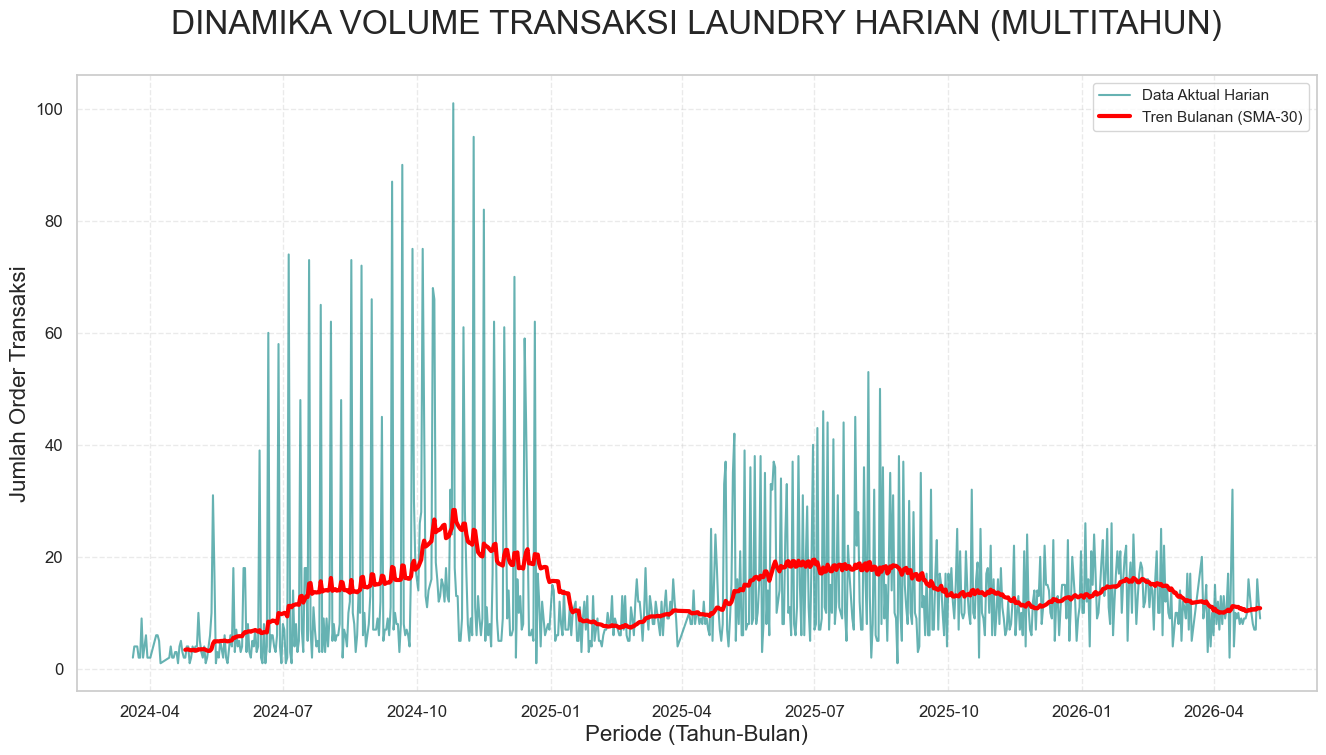

Rendering Grafik 2: Analisis Distribusi Frekuensi...


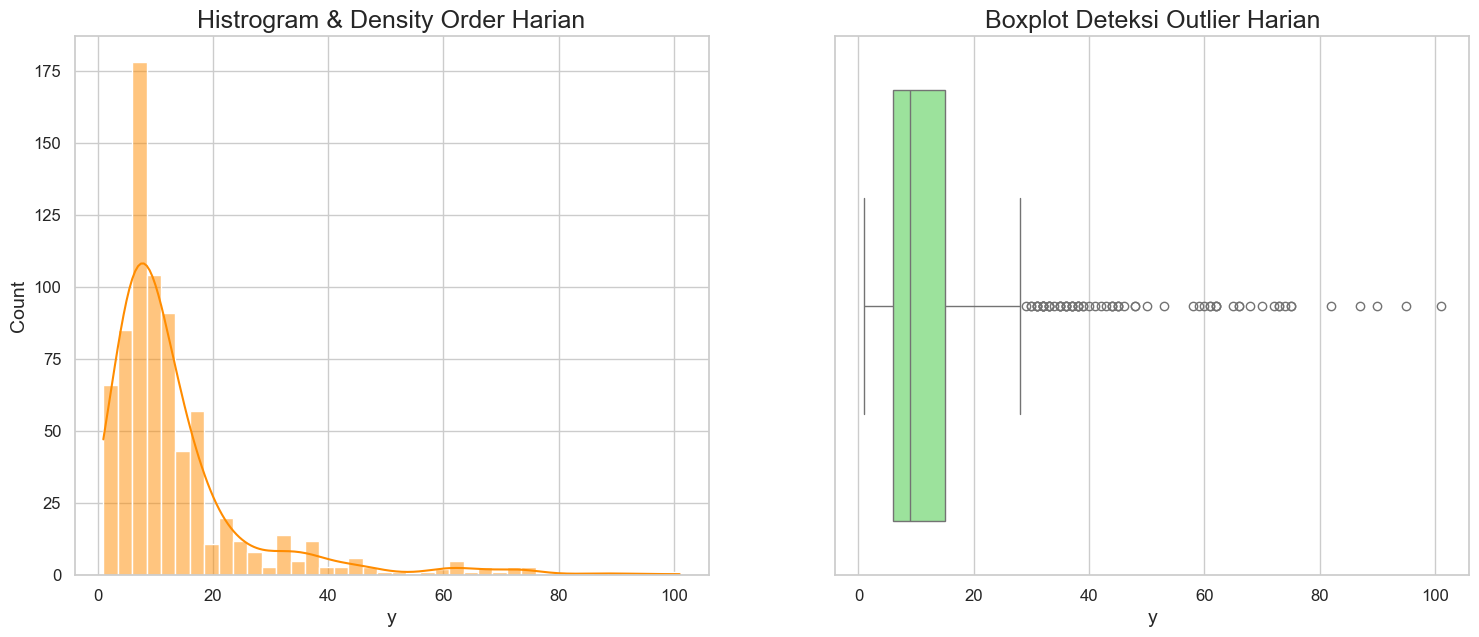

In [25]:
print("\nTAHAP 7: VISUALISASI EKSPLORASI DATA (EDA) - LEVEL 1")
print("-" * 80)
print("Rendering Grafik 1: Tren Volume Harian (Time Series)...")
plt.figure(figsize=(16, 8))
plt.plot(df_daily['ds'], df_daily['y'], color='teal', alpha=0.6, label='Data Aktual Harian')
plt.plot(df_daily['ds'], df_daily['y'].rolling(30).mean(), color='red', linewidth=3, label='Tren Bulanan (SMA-30)')
plt.title('DINAMIKA VOLUME TRANSAKSI LAUNDRY HARIAN (MULTITAHUN)', fontsize=24, pad=30)
plt.xlabel('Periode (Tahun-Bulan)', fontsize=16)
plt.ylabel('Jumlah Order Transaksi', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.savefig(os.path.join(folder_visual, '01_tren_volume_harian.png'), bbox_inches='tight', dpi=300)
plt.show()

print("Rendering Grafik 2: Analisis Distribusi Frekuensi...")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.histplot(df_daily['y'], kde=True, color='darkorange', bins=40, ax=axes[0])
axes[0].set_title('Histrogram & Density Order Harian', fontsize=18)
sns.boxplot(x=df_daily['y'], color='lightgreen', ax=axes[1])
axes[1].set_title('Boxplot Deteksi Outlier Harian', fontsize=18)
plt.savefig(os.path.join(folder_visual, '02_distribusi_dan_outlier.png'), bbox_inches='tight', dpi=300)
plt.show()


TAHAP 8: VISUALISASI EKSPLORASI DATA (EDA) - LEVEL 2
--------------------------------------------------------------------------------
Rendering Grafik 3: Komparasi Performa Layanan...


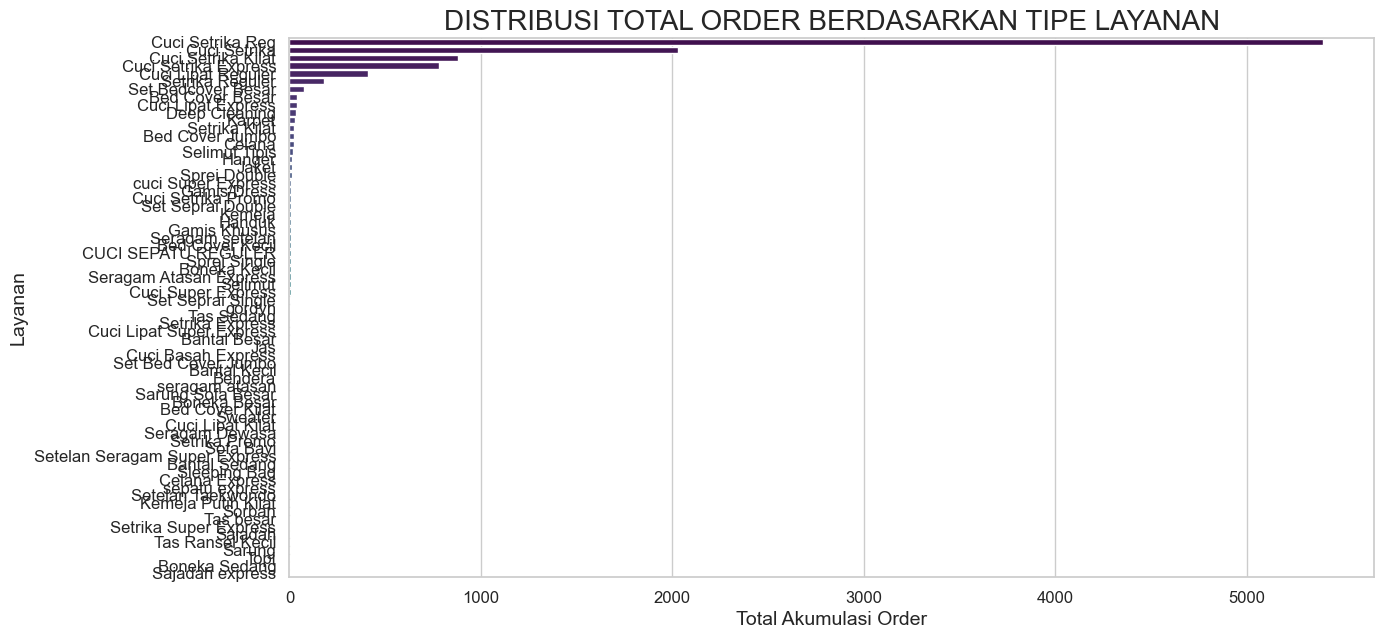

Rendering Grafik 4: Pola Musiman Mingguan...


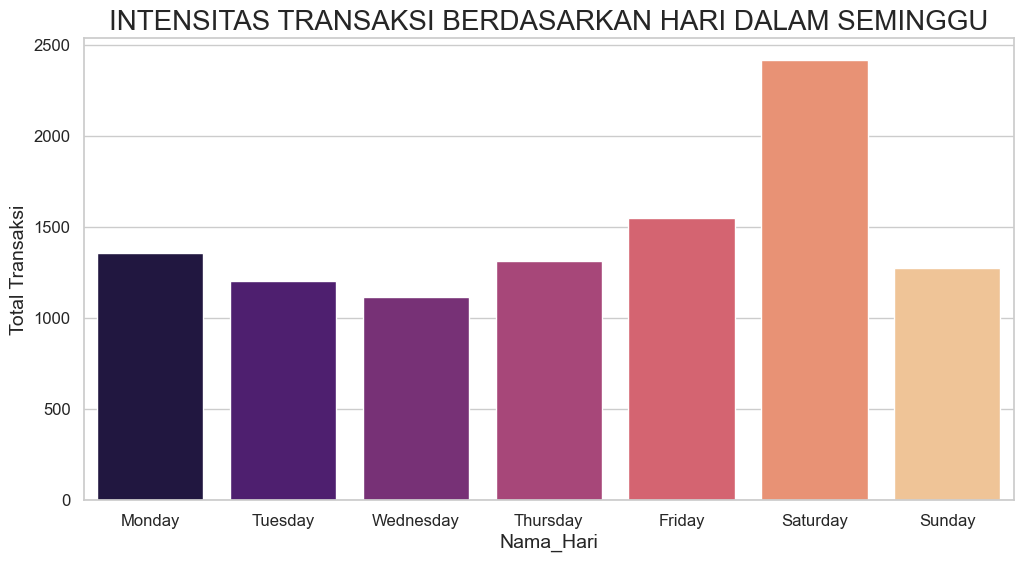

In [26]:
print("\nTAHAP 8: VISUALISASI EKSPLORASI DATA (EDA) - LEVEL 2")
print("-" * 80)
print("Rendering Grafik 3: Komparasi Performa Layanan...")
plt.figure(figsize=(14, 7))
sns.countplot(data=df_master, y='Layanan', order=df_master['Layanan'].value_counts().index, palette='viridis')
plt.title('DISTRIBUSI TOTAL ORDER BERDASARKAN TIPE LAYANAN', fontsize=20)
plt.xlabel('Total Akumulasi Order')
plt.savefig(os.path.join(folder_visual, '03_performa_layanan.png'), bbox_inches='tight', dpi=300)
plt.show()

print("Rendering Grafik 4: Pola Musiman Mingguan...")
hari_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_hari = df_master.groupby('Nama_Hari').size().reindex(hari_order)
plt.figure(figsize=(12, 6))
sns.barplot(x=df_hari.index, y=df_hari.values, palette='magma')
plt.title('INTENSITAS TRANSAKSI BERDASARKAN HARI DALAM SEMINGGU', fontsize=20)
plt.ylabel('Total Transaksi')
plt.savefig(os.path.join(folder_visual, '04_pola_mingguan.png'), bbox_inches='tight', dpi=300)
plt.show()


TAHAP 9: VISUALISASI EKSPLORASI DATA (EDA) - LEVEL 3
--------------------------------------------------------------------------------
Rendering Grafik 5: Heatmap Densitas Transaksi (Hari vs Bulan)...


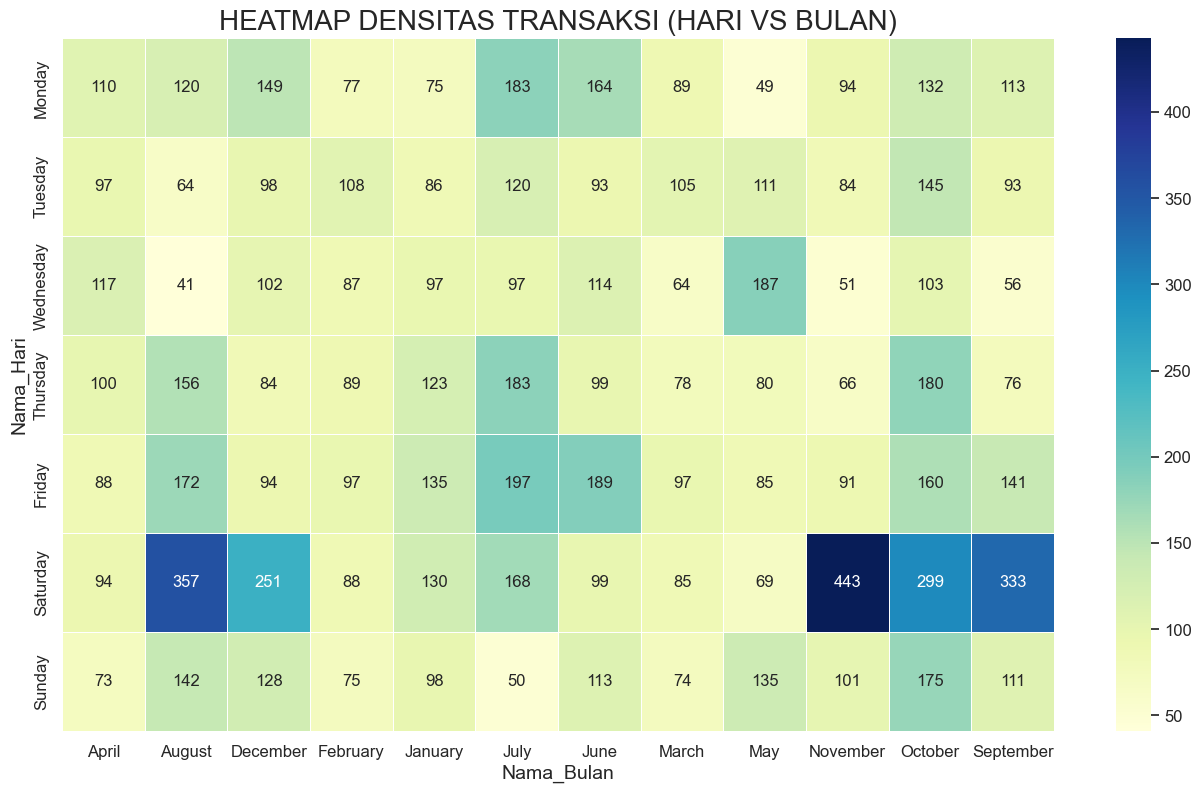

Rendering Grafik 6: Scatter Plot Berat vs Total Biaya...


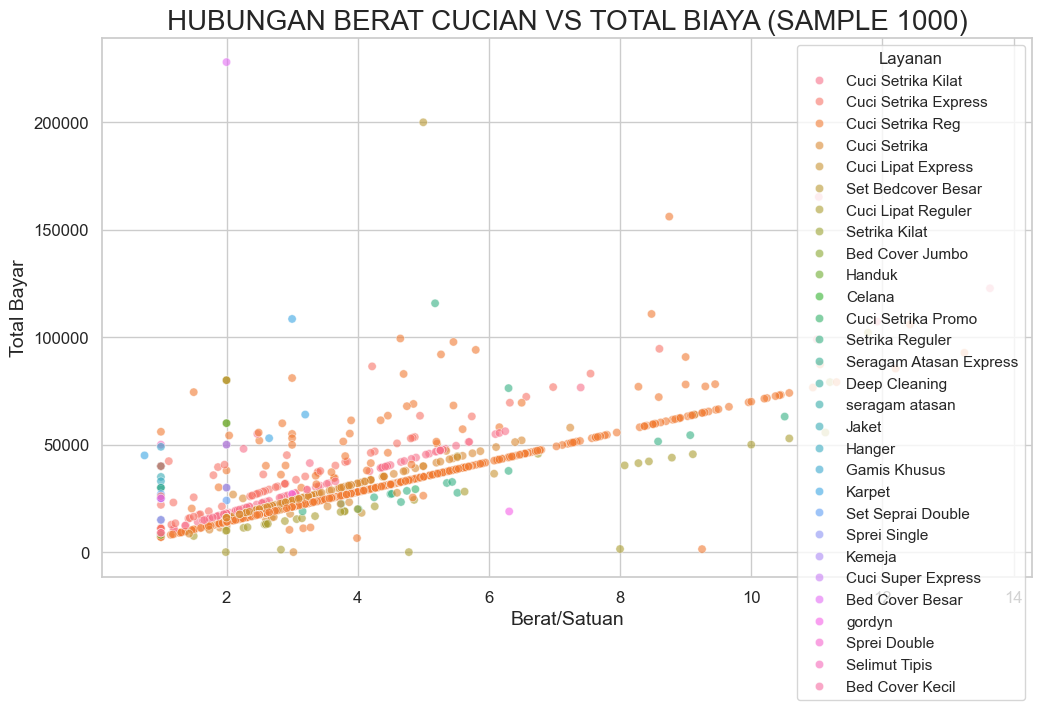

Rendering Grafik 7: Analisis Jam Operasional Sibuk...
Rendering Grafik 8: Distribusi Dominasi Metode Pembayaran...


<Figure size 1400x600 with 0 Axes>

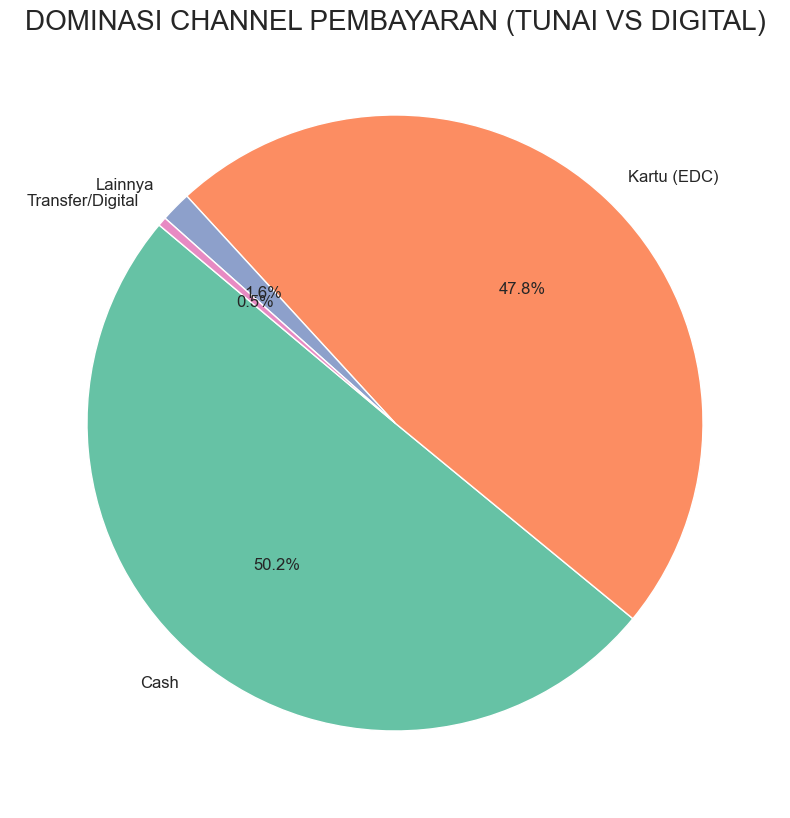


Rendering Grafik 21: Stacked Revenue Stream by Payment Type...


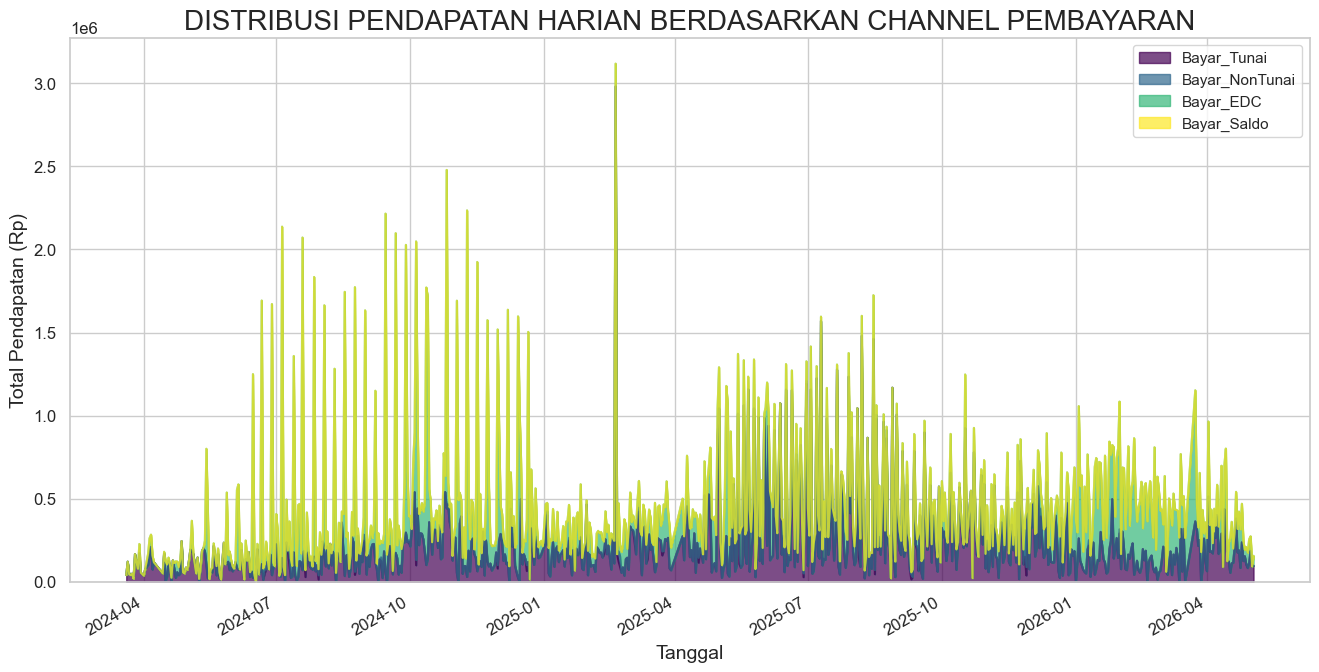

Rendering Grafik 9: Analisis Pareto Pelanggan (Top 20 Revenue)...


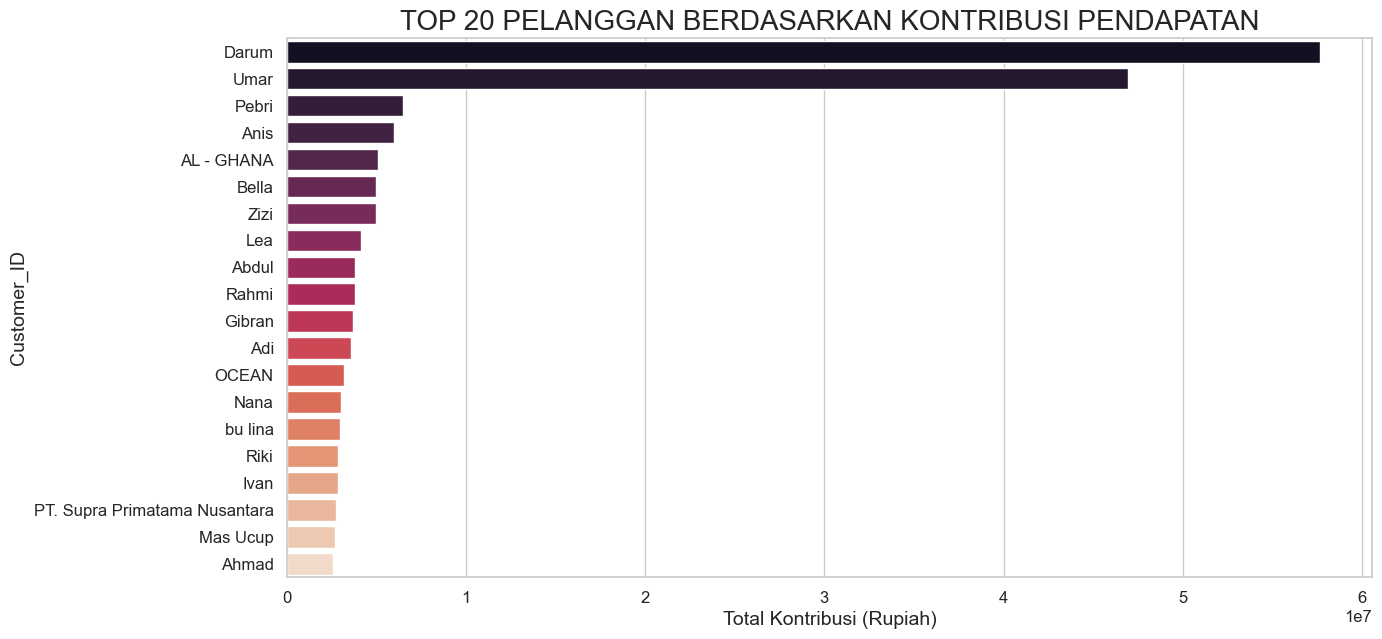

Rendering Grafik 10: Heatmap Korelasi Variabel Numerik...


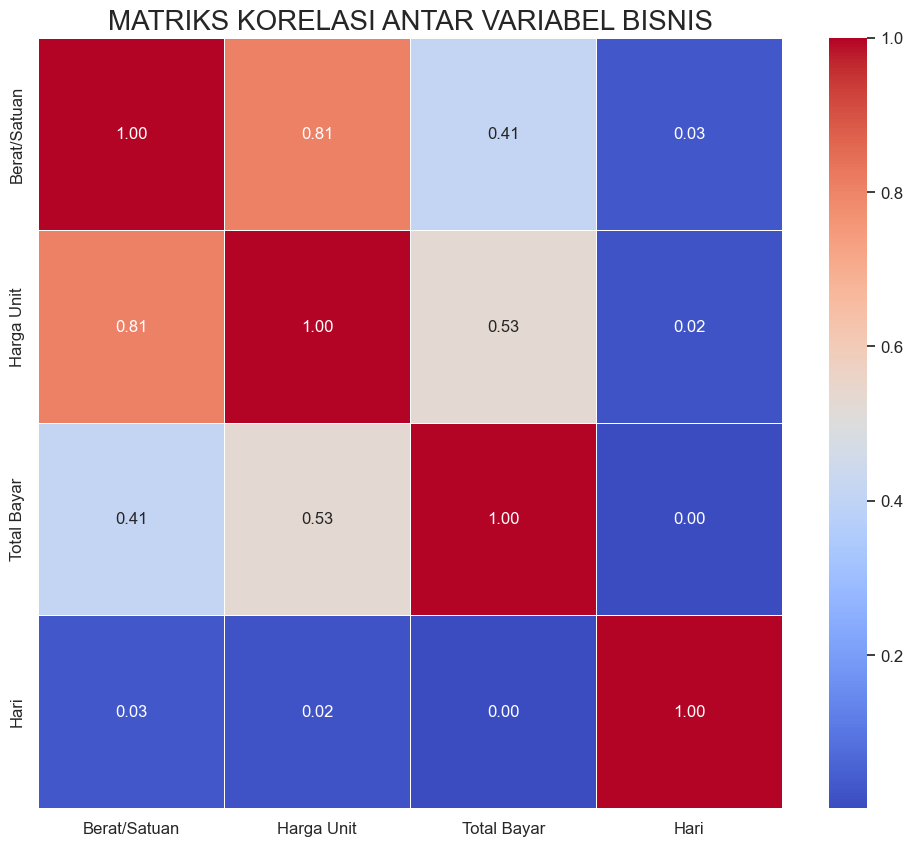

In [27]:
print("\nTAHAP 9: VISUALISASI EKSPLORASI DATA (EDA) - LEVEL 3")
print("-" * 80)
print("Rendering Grafik 5: Heatmap Densitas Transaksi (Hari vs Bulan)...")
pivot_hb = df_master.pivot_table(index='Nama_Hari', columns='Nama_Bulan', values='No. Transaksi', aggfunc='count')
pivot_hb = pivot_hb.reindex(hari_order)
plt.figure(figsize=(16, 9))
sns.heatmap(pivot_hb, annot=True, fmt='g', cmap='YlGnBu', linewidths=.5)
plt.title('HEATMAP DENSITAS TRANSAKSI (HARI VS BULAN)', fontsize=20)
plt.savefig(os.path.join(folder_visual, '05_heatmap_densitas.png'), bbox_inches='tight', dpi=300)
plt.show()

print("Rendering Grafik 6: Scatter Plot Berat vs Total Biaya...")
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_master.sample(1000), x='Berat/Satuan', y='Total Bayar', hue='Layanan', alpha=0.6)
plt.title('HUBUNGAN BERAT CUCIAN VS TOTAL BIAYA (SAMPLE 1000)', fontsize=20)
plt.savefig(os.path.join(folder_visual, '06_scatter_berat_biaya.png'), bbox_inches='tight', dpi=300)
plt.show()

print("Rendering Grafik 7: Analisis Jam Operasional Sibuk...")
plt.figure(figsize=(14, 6))
# Ekstrak jam dari kolom Jam_Masuk jika format string HH:MM
if 'Jam_Masuk' in df_master.columns:
    df_master['Jam'] = df_master['Jam_Masuk'].str.split(':').str[0].astype(float)
    sns.histplot(df_master['Jam'], bins=24, kde=True, color='purple')
    plt.title('DISTRIBUSI TRANSAKSI BERDASARKAN JAM OPERASIONAL', fontsize=20)
    plt.xlabel('Jam (24-Hour Format)')
    plt.ylabel('Frekuensi Order')
    plt.xticks(range(0, 24))
    plt.savefig(os.path.join(folder_visual, '07_distribusi_jam_sibuk.png'), bbox_inches='tight', dpi=300)
    plt.show()

print("Rendering Grafik 8: Distribusi Dominasi Metode Pembayaran...")
plt.figure(figsize=(10, 10))
metode_counts = df_master['Metode_Utama'].value_counts()
plt.pie(metode_counts, labels=metode_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set2'))
plt.title('DOMINASI CHANNEL PEMBAYARAN (TUNAI VS DIGITAL)', fontsize=20)
plt.savefig(os.path.join(folder_visual, '08_dominasi_channel_pembayaran.png'), bbox_inches='tight', dpi=300)
plt.show()

print("\nRendering Grafik 21: Stacked Revenue Stream by Payment Type...")
plt.figure(figsize=(16, 8))
df_finance = df_master.groupby('Tanggal')[['Bayar_Tunai', 'Bayar_NonTunai', 'Bayar_EDC', 'Bayar_Saldo']].sum()
df_finance.plot(kind='area', stacked=True, ax=plt.gca(), alpha=0.7, colormap='viridis')
plt.title('DISTRIBUSI PENDAPATAN HARIAN BERDASARKAN CHANNEL PEMBAYARAN', fontsize=20)
plt.ylabel('Total Pendapatan (Rp)')
plt.savefig(os.path.join(folder_visual, '21_revenue_stream_breakdown.png'), bbox_inches='tight', dpi=300)
plt.show()

print("Rendering Grafik 9: Analisis Pareto Pelanggan (Top 20 Revenue)...")
plt.figure(figsize=(14, 7))
top_customers = df_master.groupby('Customer_ID')['Total Bayar'].sum().sort_values(ascending=False).head(20)
sns.barplot(x=top_customers.values, y=top_customers.index, palette='rocket')
plt.title('TOP 20 PELANGGAN BERDASARKAN KONTRIBUSI PENDAPATAN', fontsize=20)
plt.xlabel('Total Kontribusi (Rupiah)')
plt.savefig(os.path.join(folder_visual, '09_pareto_pelanggan.png'), bbox_inches='tight', dpi=300)
plt.show()

print("Rendering Grafik 10: Heatmap Korelasi Variabel Numerik...")
plt.figure(figsize=(12, 10))
corr_matrix = df_master[['Berat/Satuan', 'Harga Unit', 'Total Bayar', 'Hari']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('MATRIKS KORELASI ANTAR VARIABEL BISNIS', fontsize=20)
plt.savefig(os.path.join(folder_visual, '10_heatmap_korelasi.png'), bbox_inches='tight', dpi=300)
plt.show()


TAHAP 10: UJI STATISTIK DAN ANALISIS STASIONERITAS
--------------------------------------------------------------------------------
1. Uji Normalitas Shapiro-Wilk (Data Harian):
- Statistik Uji: 0.6753
- P-Value      : 1.6295e-35
  Kesimpulan: Data tidak mengikuti distribusi Normal (Tolak H0)

Rendering Grafik 11: Tren Akumulasi Pendapatan (Growth Curve)...


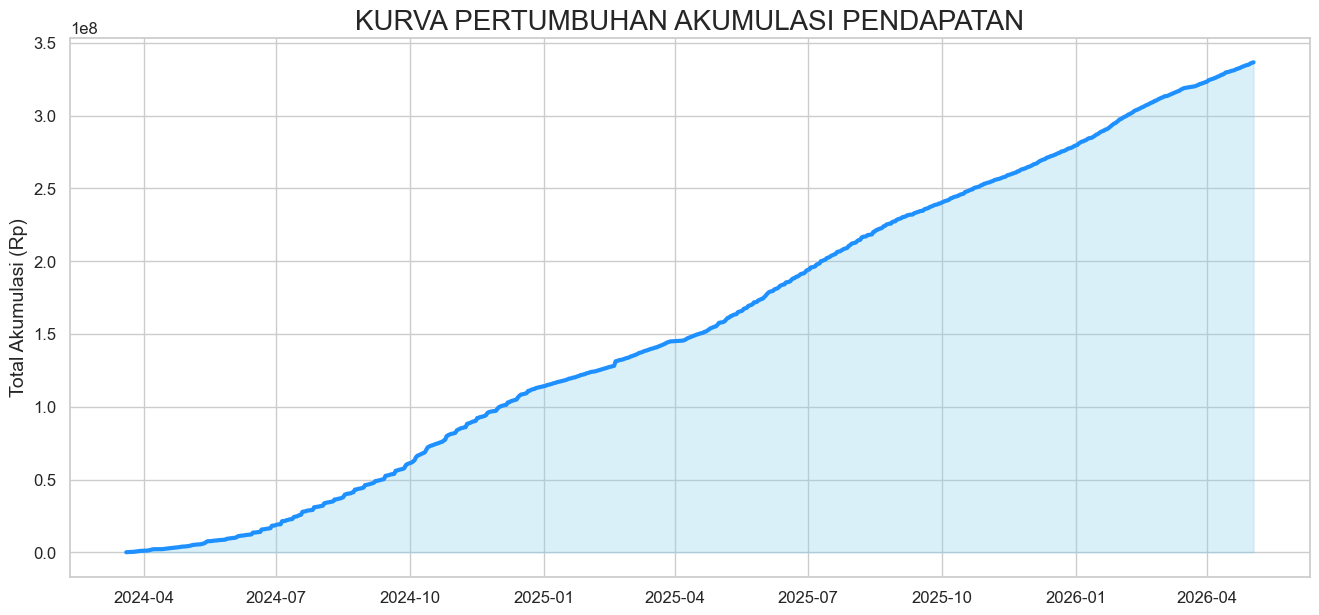


2. Uji Stasioneritas Rolling Statistics:


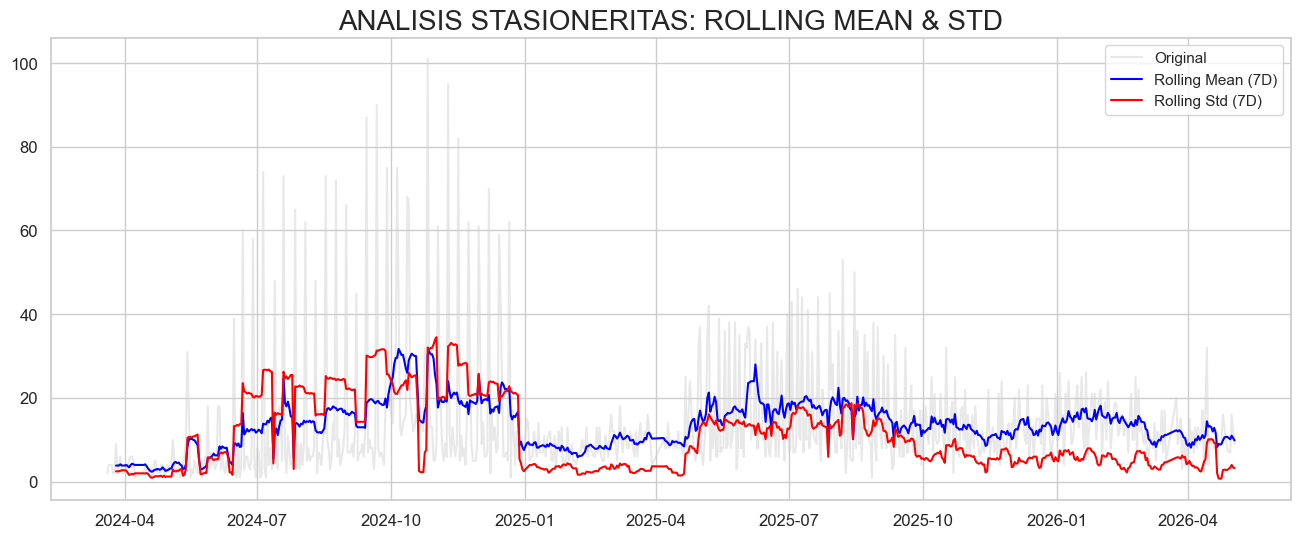


Rendering Grafik 13: Average Transaction Value (ATV) per Bulan...


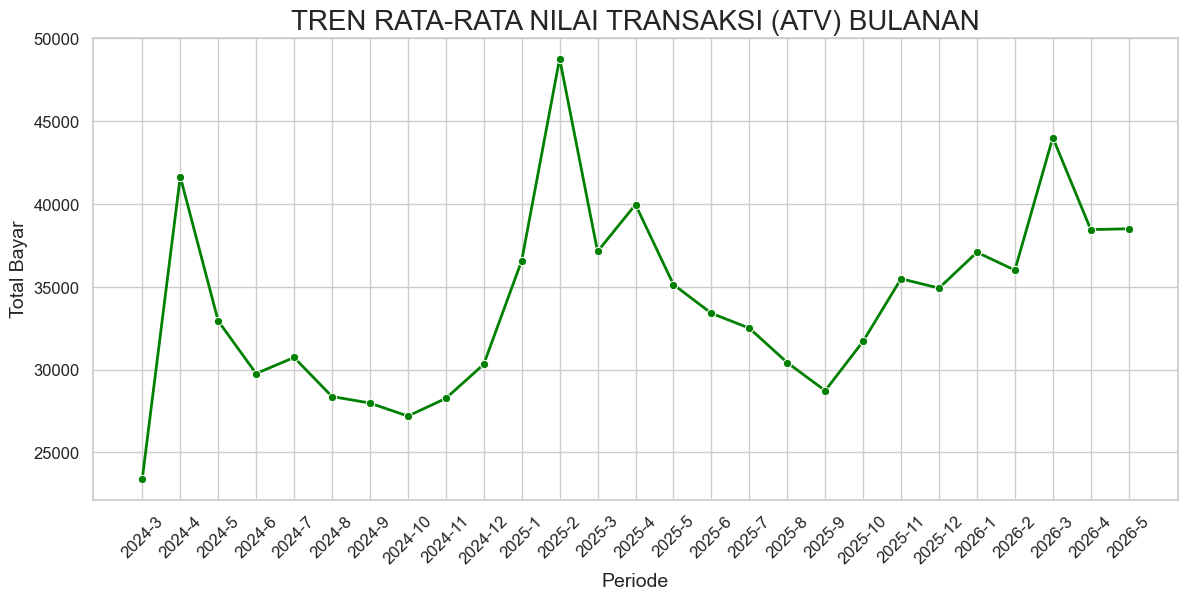

In [28]:
print("\nTAHAP 10: UJI STATISTIK DAN ANALISIS STASIONERITAS")
print("-" * 80)
print("1. Uji Normalitas Shapiro-Wilk (Data Harian):")
s_stat, p_val = stats.shapiro(df_daily['y'])
print(f"- Statistik Uji: {s_stat:.4f}")
print(f"- P-Value      : {p_val:.4e}")
if p_val > 0.05:
    print("  Kesimpulan: Data mengikuti distribusi Normal (Gagal menolak H0)")
else:
    print("  Kesimpulan: Data tidak mengikuti distribusi Normal (Tolak H0)")

print("\nRendering Grafik 11: Tren Akumulasi Pendapatan (Growth Curve)...")
plt.figure(figsize=(16, 7))
df_growth = df_master.groupby('Tanggal')['Total Bayar'].sum().cumsum()
plt.fill_between(df_growth.index, df_growth.values, color='skyblue', alpha=0.3)
plt.plot(df_growth.index, df_growth.values, color='dodgerblue', linewidth=3)
plt.title('KURVA PERTUMBUHAN AKUMULASI PENDAPATAN', fontsize=20)
plt.ylabel('Total Akumulasi (Rp)')
plt.savefig(os.path.join(folder_visual, '11_pertumbuhan_akumulasi.png'), bbox_inches='tight', dpi=300)
plt.show()

print("\n2. Uji Stasioneritas Rolling Statistics:")
roll_mean = df_daily['y'].rolling(window=7).mean()
roll_std = df_daily['y'].rolling(window=7).std()
plt.figure(figsize=(16, 6))
plt.plot(df_daily['ds'], df_daily['y'], color='lightgrey', alpha=0.5, label='Original')
plt.plot(df_daily['ds'], roll_mean, color='blue', label='Rolling Mean (7D)')
plt.plot(df_daily['ds'], roll_std, color='red', label='Rolling Std (7D)')
plt.title('ANALISIS STASIONERITAS: ROLLING MEAN & STD', fontsize=20)
plt.legend()
plt.savefig(os.path.join(folder_visual, '12_uji_stasioneritas.png'), bbox_inches='tight', dpi=300)
plt.show()

print("\nRendering Grafik 13: Average Transaction Value (ATV) per Bulan...")
plt.figure(figsize=(14, 6))
df_atv = df_master.groupby(['Tahun', 'Bulan'])['Total Bayar'].mean().reset_index()
df_atv['Periode'] = df_atv['Tahun'].astype(str) + '-' + df_atv['Bulan'].astype(str)
sns.lineformat = sns.lineplot(data=df_atv, x='Periode', y='Total Bayar', marker='o', color='green', linewidth=2)
plt.title('TREN RATA-RATA NILAI TRANSAKSI (ATV) BULANAN', fontsize=20)
plt.xticks(rotation=45)
plt.savefig(os.path.join(folder_visual, '13_atv_bulanan.png'), bbox_inches='tight', dpi=300)
plt.show()


In [29]:
print("\nTAHAP 11: KONFIGURASI DAN PARAMETERISASI MODEL PROPHET (ADVANCED TUNING)")
print("-" * 80)
print("Konfigurasi Mesin Peramalan (Prophet Advanced):")
print("- Menambahkan fitur Libur Nasional (Indonesia)")
print("- Optimasi Changepoint Prior Scale: 0.1")

# Definisi Hari Libur Nasional (Indonesia 2024-2025)
holidays_list = [
    {'holiday': 'Lebaran', 'ds': '2024-04-10', 'lower_window': -2, 'upper_window': 5},
    {'holiday': 'Lebaran', 'ds': '2025-03-31', 'lower_window': -2, 'upper_window': 5},
    {'holiday': 'Tahun_Baru', 'ds': '2024-01-01', 'lower_window': -1, 'upper_window': 1},
    {'holiday': 'Tahun_Baru', 'ds': '2025-01-01', 'lower_window': -1, 'upper_window': 1},
    {'holiday': 'Natal', 'ds': '2024-12-25', 'lower_window': -1, 'upper_window': 1},
    {'holiday': 'Natal', 'ds': '2025-12-25', 'lower_window': -1, 'upper_window': 1}
]
df_holidays = pd.DataFrame(holidays_list)
df_holidays['ds'] = pd.to_datetime(df_holidays['ds'])

# Menyiapkan Regressor Eksternal (Weekend & Gajian)
df_regressors = df_master.groupby(df_master['Tanggal'].dt.date)[['Is_Weekend', 'Gajian_Effect']].max().reset_index()
df_regressors.columns = ['ds', 'Is_Weekend', 'Gajian_Effect']
df_regressors['ds'] = pd.to_datetime(df_regressors['ds'])

# Gabungkan ke df_daily sebelum fitting
df_daily = pd.merge(df_daily, df_regressors, on='ds', how='left')

model_final = Prophet(
    growth='linear',
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    holidays=df_holidays,
    changepoint_prior_scale=0.1, # Lebih sensitif terhadap perubahan tren
    seasonality_prior_scale=10.0,
    interval_width=0.95
)

# Menambahkan Regressor ke Model
model_final.add_regressor('Is_Weekend')
model_final.add_regressor('Gajian_Effect')


TAHAP 11: KONFIGURASI DAN PARAMETERISASI MODEL PROPHET (ADVANCED TUNING)
--------------------------------------------------------------------------------
Konfigurasi Mesin Peramalan (Prophet Advanced):
- Menambahkan fitur Libur Nasional (Indonesia)
- Optimasi Changepoint Prior Scale: 0.1


In [30]:
print("\nTAHAP 12: PELATIHAN MODEL PADA DATA HISTORIS (FITTING)")
print("-" * 80)
print(f"Menginisialisasi proses pembelajaran pada {len(df_daily)} observasi...")
waktu_start = time.time()
model_final.fit(df_daily)
waktu_end = time.time()
print(f"Status: [OK] Model berhasil dilatih dalam {waktu_end - waktu_start:.2f} detik.")


TAHAP 12: PELATIHAN MODEL PADA DATA HISTORIS (FITTING)
--------------------------------------------------------------------------------
Menginisialisasi proses pembelajaran pada 750 observasi...


01:26:35 - cmdstanpy - INFO - Chain [1] start processing
01:26:35 - cmdstanpy - INFO - Chain [1] done processing


Status: [OK] Model berhasil dilatih dalam 0.17 detik.


In [31]:
print("\nTAHAP 13: PERSISTENSI MODEL (MODEL EXPORT & SERIALIZATION)")
print("-" * 80)
path_model_json = os.path.join(folder_models, 'prophet_laundry_model.json')
path_model_pkl = os.path.join(folder_models, 'prophet_laundry_model.pkl')

print(f"Mengekspor struktur model ke: {path_model_json}...")
with open(path_model_json, 'w') as f:
    json.dump(model_to_json(model_final), f)

print(f"Mengekspor objek model ke: {path_model_pkl}...")
with open(path_model_pkl, 'wb') as f:
    pickle.dump(model_final, f)

print("Status: [SUKSES] Model berhasil disimpan dalam format JSON dan PKL.")



TAHAP 13: PERSISTENSI MODEL (MODEL EXPORT & SERIALIZATION)
--------------------------------------------------------------------------------
Mengekspor struktur model ke: ../models/prophet_laundry_model.json...
Mengekspor objek model ke: ../models/prophet_laundry_model.pkl...
Status: [SUKSES] Model berhasil disimpan dalam format JSON dan PKL.


In [32]:
print("-" * 80)
print("\nTAHAP 14: VALIDASI SILANG DAN DIAGNOSTIK MODEL (CROSS VALIDATION)")
print("Sistem melakukan Backtesting otomatis untuk mengukur tingkat error...")
try:
    df_cv = cross_validation(
        model_final, 
        initial='730 days', 
        period='90 days', 
        horizon='30 days'
    )
    df_metrics = performance_metrics(df_cv)
    print("\nMetrik Performa Model (Average over Horizons):")
    print(df_metrics[['horizon', 'mae', 'rmse', 'mape', 'mdape']].head().to_string())
except Exception as cv_e:
    print(f"Catatan: Cross validation dilewati (Kemungkinan keterbatasan panjang data). Detail: {str(cv_e)}")

--------------------------------------------------------------------------------

TAHAP 14: VALIDASI SILANG DAN DIAGNOSTIK MODEL (CROSS VALIDATION)
Sistem melakukan Backtesting otomatis untuk mengukur tingkat error...


  0%|          | 0/1 [00:00<?, ?it/s]01:26:35 - cmdstanpy - INFO - Chain [1] start processing
01:26:35 - cmdstanpy - INFO - Chain [1] done processing
100%|██████████| 1/1 [00:00<00:00,  6.53it/s]



Metrik Performa Model (Average over Horizons):
  horizon       mae      rmse      mape     mdape
0  3 days  5.197313  6.366936  0.510149  0.576068
1  4 days  2.405096  2.671283  0.302367  0.224120
2  5 days  2.271999  2.472949  0.203503  0.224120
3  6 days  2.453786  2.592283  0.239540  0.224120
4  7 days  2.602138  2.705168  0.232652  0.215023


In [33]:
print("\nTAHAP 15: GENERASI PERAMALAN MASA DEPAN (MULTI-HORIZON STRATEGIC FORECASTING)")
print("-" * 80)
horizon_prediksi = 1095 # 3 Tahun kedepan sesuai permintaan
print(f"Membangun proyeksi waktu untuk {horizon_prediksi} hari mendatang (Long-term Strategy)...")
future_matrix = model_final.make_future_dataframe(periods=horizon_prediksi, freq='D')

# Re-generate Regressors untuk masa depan
future_matrix['Is_Weekend'] = future_matrix['ds'].dt.weekday.apply(lambda x: 1 if x >= 5 else 0)
future_matrix['Gajian_Effect'] = future_matrix['ds'].dt.day.apply(lambda x: 1 if x >= 25 or x <= 5 else 0)

print("Mengkalkulasi nilai estimasi menggunakan mesin inferensi...")
forecast_output = model_final.predict(future_matrix)

print("\nPratinjau Hasil Prediksi (30 Hari Terakhir):")
print(forecast_output[['ds', 'yhat', 'yhat_lower', 'yhat_upper', 'trend']].tail().to_string())


TAHAP 15: GENERASI PERAMALAN MASA DEPAN (MULTI-HORIZON STRATEGIC FORECASTING)
--------------------------------------------------------------------------------
Membangun proyeksi waktu untuk 1095 hari mendatang (Long-term Strategy)...
Mengkalkulasi nilai estimasi menggunakan mesin inferensi...

Pratinjau Hasil Prediksi (30 Hari Terakhir):
             ds       yhat  yhat_lower  yhat_upper      trend
1840 2029-04-28  30.719547   -5.960503   64.929922  24.054622
1841 2029-04-29  20.117941  -15.564177   56.370644  24.063171
1842 2029-04-30  21.349373  -16.490701   56.555391  24.071720
1843 2029-05-01  19.960312  -16.922384   55.411431  24.080270
1844 2029-05-02  19.621326  -17.120775   56.732180  24.088819


In [34]:
print("\nTAHAP 16: EVALUASI AKURASI MODEL (BACKTESTING METRICS)")
print("-" * 80)
print("Membandingkan data aktual vs estimasi pada periode historis...")
y_actual = df_daily['y'].values
y_predict = forecast_output['yhat'].iloc[:len(df_daily)].values

v_mae = mean_absolute_error(y_actual, y_predict)
v_mse = mean_squared_error(y_actual, y_predict)
v_rmse = np.sqrt(v_mse)
v_mape = np.mean(np.abs((y_actual - y_predict) / y_actual)) * 100
v_r2 = r2_score(y_actual, y_predict)
v_wape = (np.sum(np.abs(y_actual - y_predict)) / np.sum(y_actual)) * 100

print("-" * 50)
print(f"1. Mean Absolute Error (MAE)     : {v_mae:.4f} unit")
print(f"2. Root Mean Squared Error (RMSE): {v_rmse:.4f} unit")
print(f"3. Mean Abs Pct Error (MAPE)     : {v_mape:.2f}%")
print(f"4. Weighted Abs Pct Error (WAPE) : {v_wape:.2f}%")
print(f"5. R-Squared (Accuracy Score)    : {v_r2:.4f}")
print("-" * 50)


TAHAP 16: EVALUASI AKURASI MODEL (BACKTESTING METRICS)
--------------------------------------------------------------------------------
Membandingkan data aktual vs estimasi pada periode historis...
--------------------------------------------------
1. Mean Absolute Error (MAE)     : 8.3596 unit
2. Root Mean Squared Error (RMSE): 12.7235 unit
3. Mean Abs Pct Error (MAPE)     : 100.97%
4. Weighted Abs Pct Error (WAPE) : 61.31%
5. R-Squared (Accuracy Score)    : 0.1659
--------------------------------------------------



TAHAP 17: EVALUASI KLASIFIKASI PERFORMA MODEL (CLASSIFICATION METRICS)
--------------------------------------------------------------------------------
Sistem mengkonversi data regresi menjadi klasifikasi 'Busy vs Normal' Day...
Metrik Klasifikasi (Threshold > 9.0 order):
1. Accuracy Score   : 55.60%
2. Precision Score  : 53.04%
3. Recall Score     : 89.22%
4. F1-Score         : 66.53%
5. ROC-AUC Score    : 0.6545

Rendering Grafik 24: Confusion Matrix Analysis...


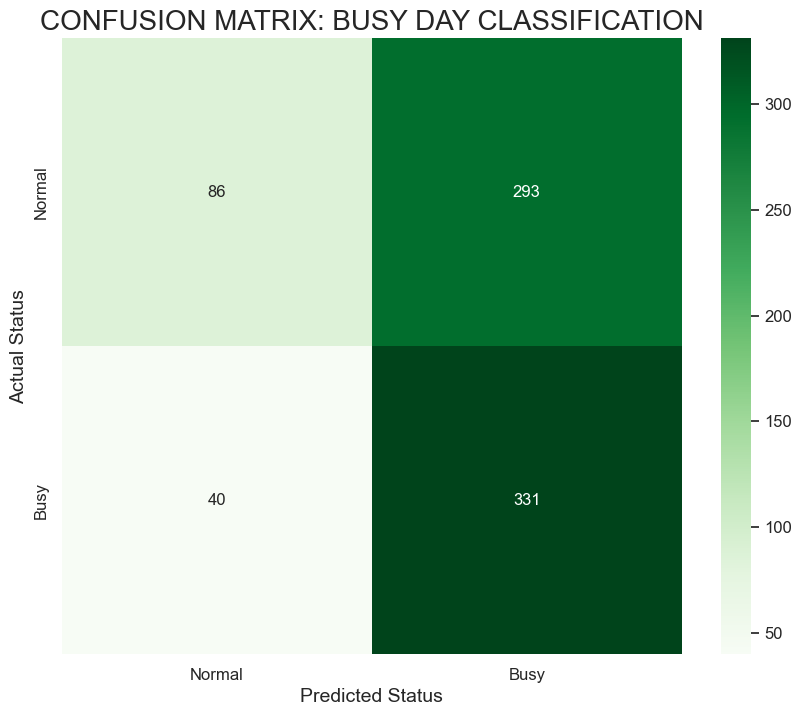


Rendering Grafik 25: ROC Curve Analysis...


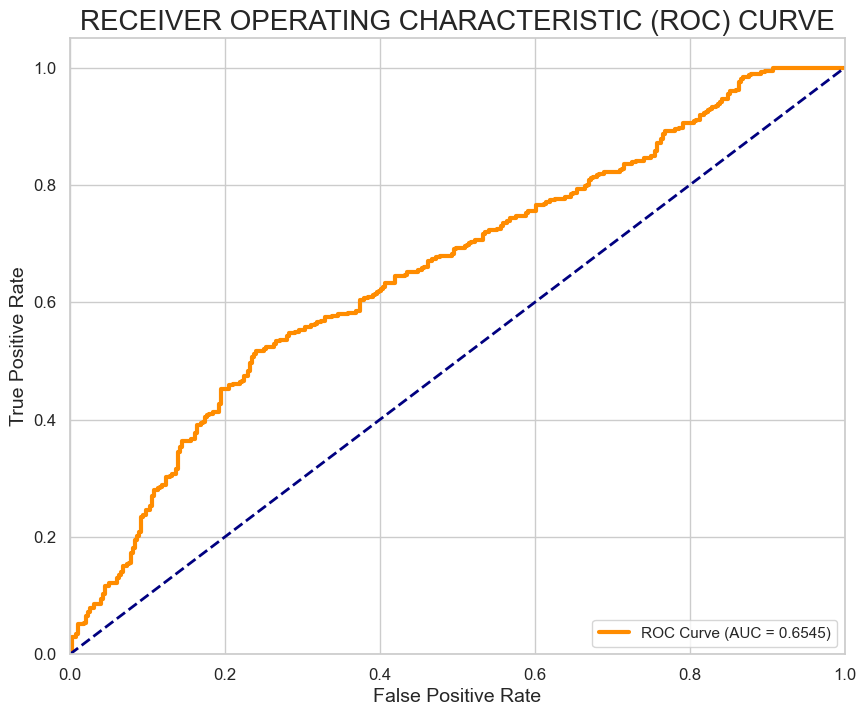

In [35]:
print("\nTAHAP 17: EVALUASI KLASIFIKASI PERFORMA MODEL (CLASSIFICATION METRICS)")
print("-" * 80)
print("Sistem mengkonversi data regresi menjadi klasifikasi 'Busy vs Normal' Day...")
# Threshold: Median harian sebagai penentu hari sibuk
threshold_busy = df_daily['y'].median()
y_actual_cat = (y_actual > threshold_busy).astype(int)
y_predict_cat = (y_predict > threshold_busy).astype(int)

acc = accuracy_score(y_actual_cat, y_predict_cat)
prec = precision_score(y_actual_cat, y_predict_cat)
rec = recall_score(y_actual_cat, y_predict_cat)
f1 = f1_score(y_actual_cat, y_predict_cat)

# Perhitungan ROC-AUC (Menggunakan y_predict sebagai skor probabilitas)
# Kita normalisasi y_predict ke range [0, 1] untuk keperluan ROC
y_predict_norm = (y_predict - y_predict.min()) / (y_predict.max() - y_predict.min())
auc_score = roc_auc_score(y_actual_cat, y_predict_norm)

print(f"Metrik Klasifikasi (Threshold > {threshold_busy} order):")
print(f"1. Accuracy Score   : {acc*100:.2f}%")
print(f"2. Precision Score  : {prec*100:.2f}%")
print(f"3. Recall Score     : {rec*100:.2f}%")
print(f"4. F1-Score         : {f1*100:.2f}%")
print(f"5. ROC-AUC Score    : {auc_score:.4f}")

print("\nRendering Grafik 24: Confusion Matrix Analysis...")
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_actual_cat, y_predict_cat)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Normal', 'Busy'], yticklabels=['Normal', 'Busy'])
plt.title('CONFUSION MATRIX: BUSY DAY CLASSIFICATION', fontsize=20)
plt.ylabel('Actual Status')
plt.xlabel('Predicted Status')
plt.savefig(os.path.join(folder_visual, '24_confusion_matrix_busy_day.png'), bbox_inches='tight', dpi=300)
plt.show()

print("\nRendering Grafik 25: ROC Curve Analysis...")
fpr, tpr, _ = roc_curve(y_actual_cat, y_predict_norm)
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('RECEIVER OPERATING CHARACTERISTIC (ROC) CURVE', fontsize=20)
plt.legend(loc="lower right")
plt.savefig(os.path.join(folder_visual, '25_roc_curve_analysis.png'), bbox_inches='tight', dpi=300)
plt.show()


TAHAP 18: VISUALISASI HASIL FORECASTING (PROPHET PLOTS)
--------------------------------------------------------------------------------
Rendering Grafik 7: Plot Utama Forecast...


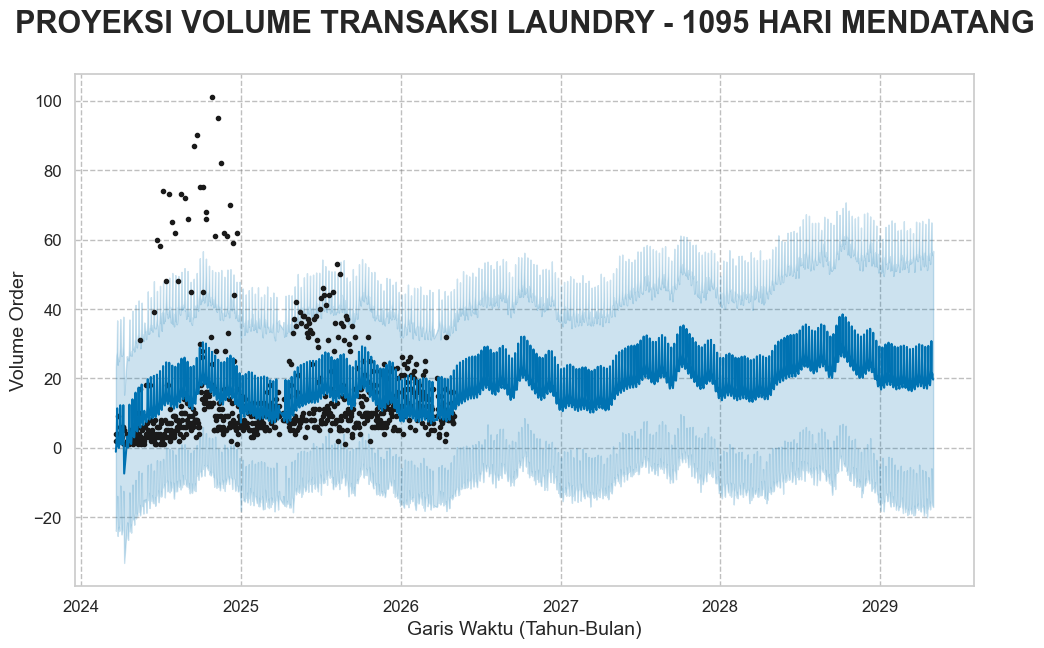

Rendering Grafik 15: Dekomposisi Komponen Musiman...


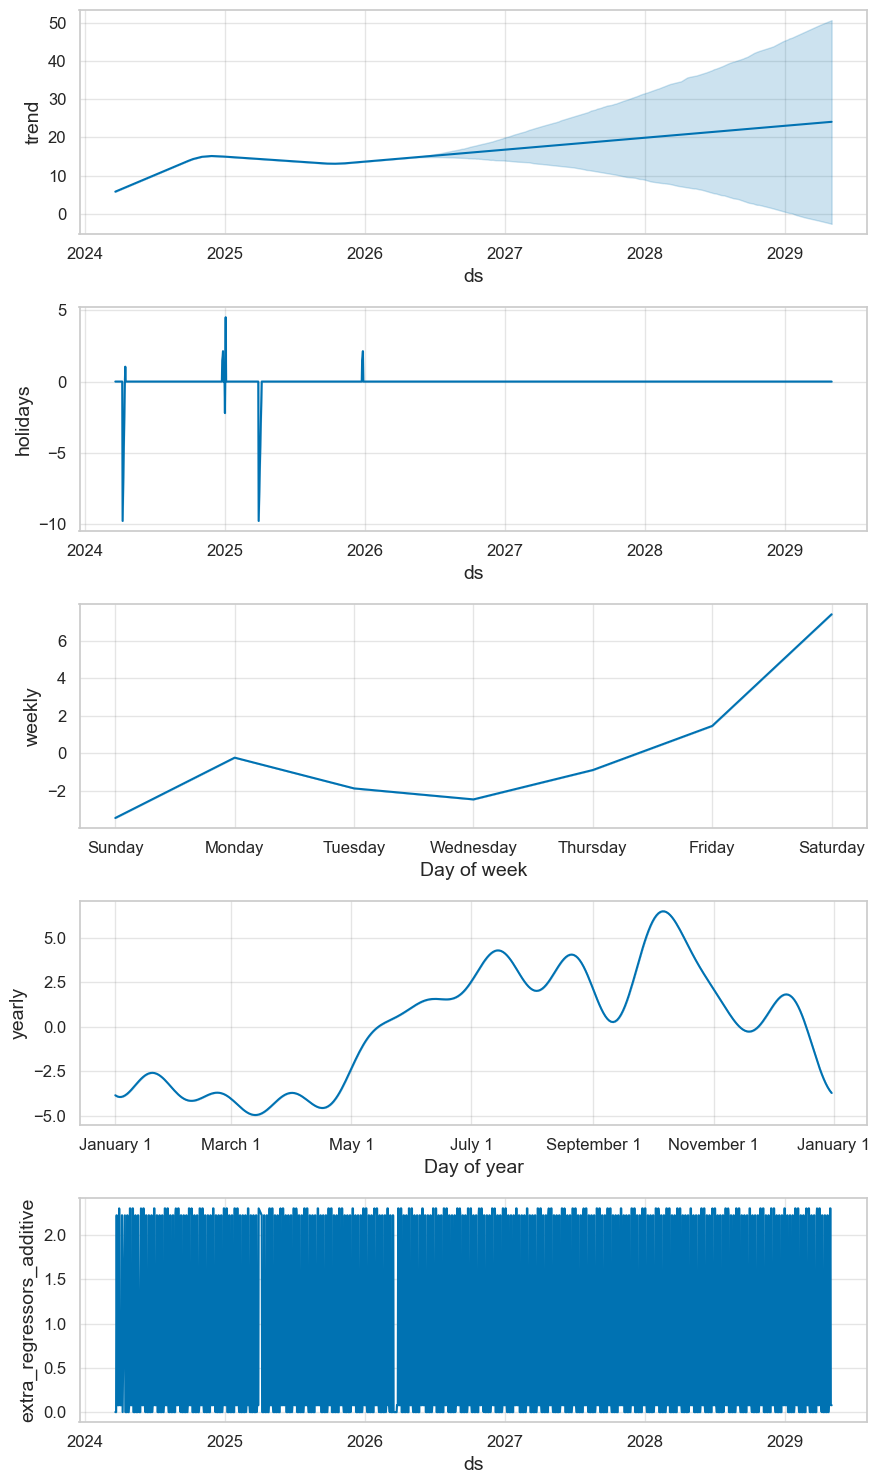


Rendering Grafik 16: Evolusi Service Mix (Quarterly)...


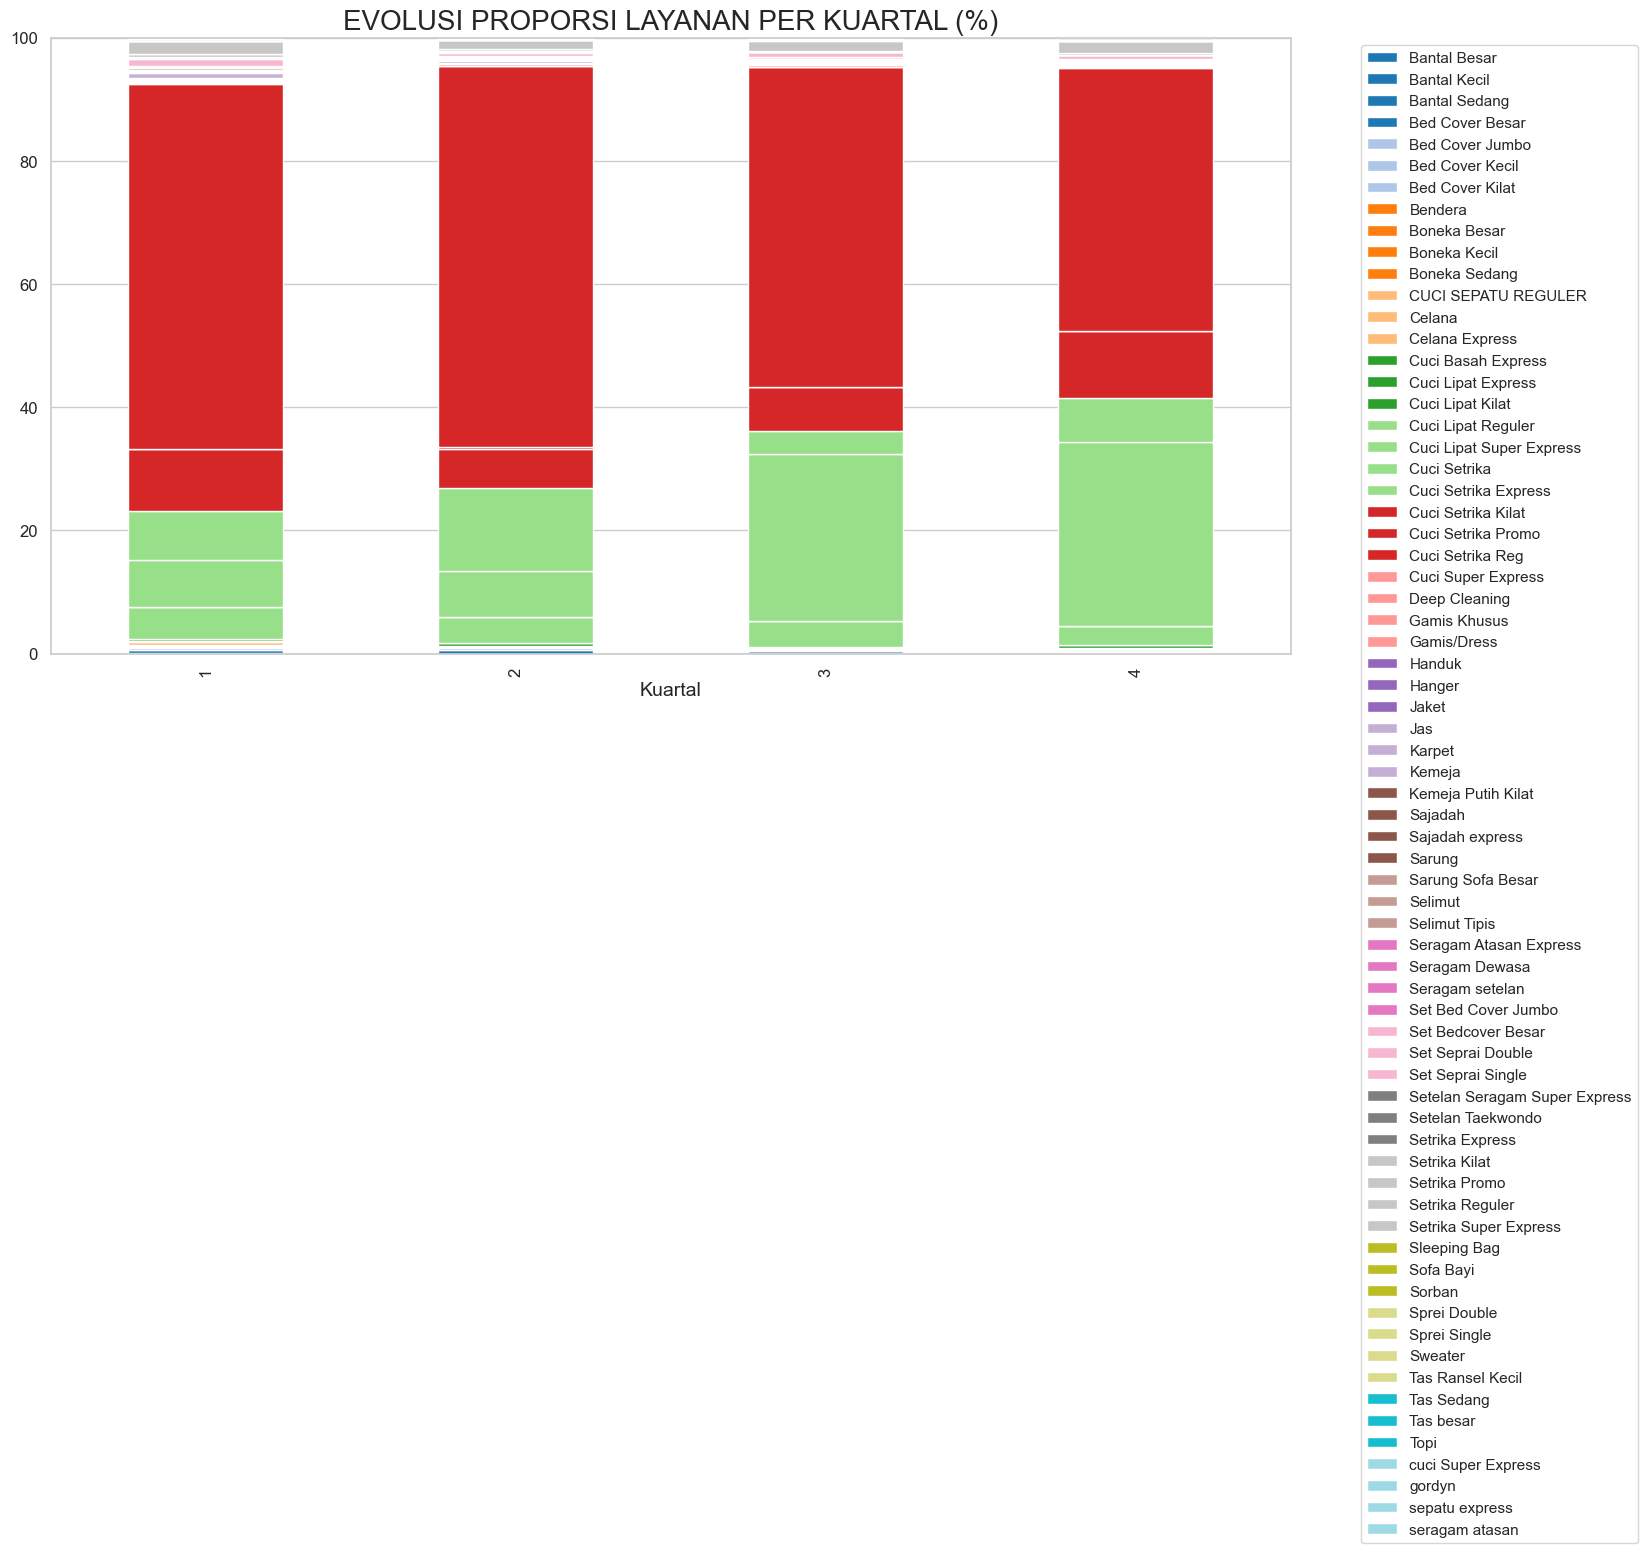

In [36]:
print("\nTAHAP 18: VISUALISASI HASIL FORECASTING (PROPHET PLOTS)")
print("-" * 80)
print("Rendering Grafik 7: Plot Utama Forecast...")
fig_main = model_final.plot(forecast_output)
plt.title(f'PROYEKSI VOLUME TRANSAKSI LAUNDRY - {horizon_prediksi} HARI MENDATANG', fontsize=22, fontweight='bold', pad=30)
plt.xlabel('Garis Waktu (Tahun-Bulan)', fontsize=14)
plt.ylabel('Volume Order', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig(os.path.join(folder_visual, '14_forecast_prophet_utama.png'), bbox_inches='tight', dpi=300)
plt.show()

print("Rendering Grafik 15: Dekomposisi Komponen Musiman...")
fig_comp = model_final.plot_components(forecast_output)
plt.savefig(os.path.join(folder_visual, '15_forecast_komponen_musiman.png'), bbox_inches='tight', dpi=300)
plt.show()

print("\nRendering Grafik 16: Evolusi Service Mix (Quarterly)...")
plt.figure(figsize=(16, 8))
service_mix = df_master.groupby(['Kuartal', 'Layanan']).size().unstack().fillna(0)
service_mix_pct = service_mix.div(service_mix.sum(axis=1), axis=0) * 100
service_mix_pct.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='tab20')
plt.title('EVOLUSI PROPORSI LAYANAN PER KUARTAL (%)', fontsize=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig(os.path.join(folder_visual, '16_service_mix_evolution.png'), bbox_inches='tight', dpi=300)
plt.show()


TAHAP 19: ANALISIS VALIDASI VISUAL (ACTUAL VS ESTIMATED)
--------------------------------------------------------------------------------
Rendering Grafik 9: Perbandingan Data Historis vs Model Fitting...


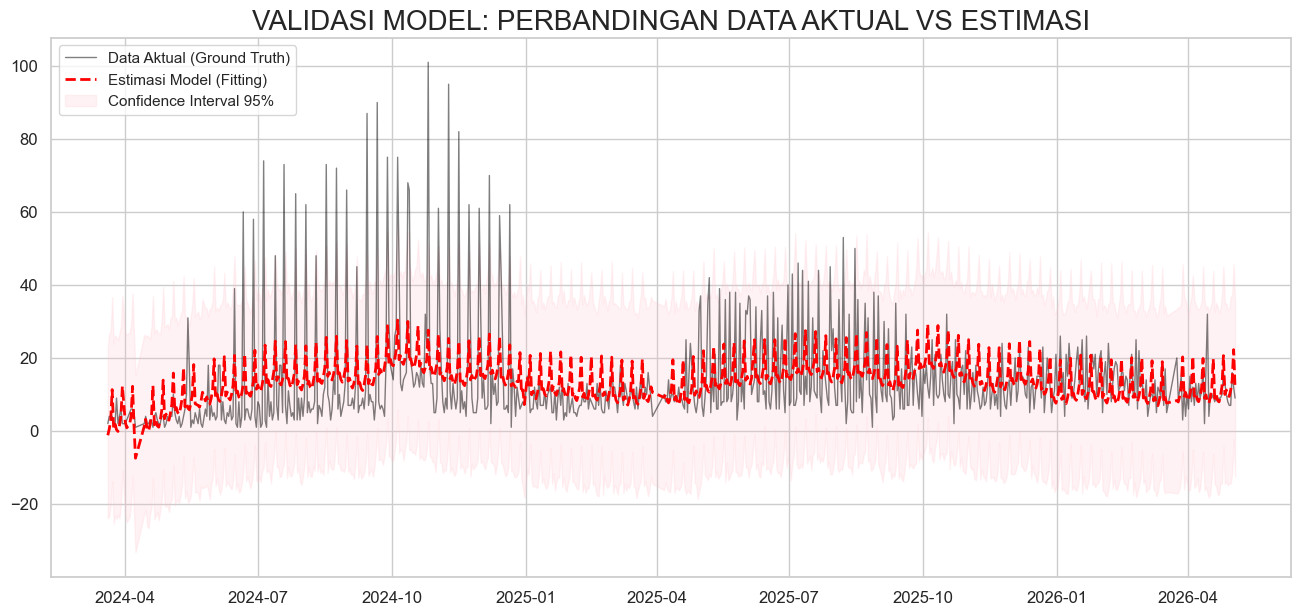


Rendering Grafik 18: Analisis Distribusi Error (Residuals)...


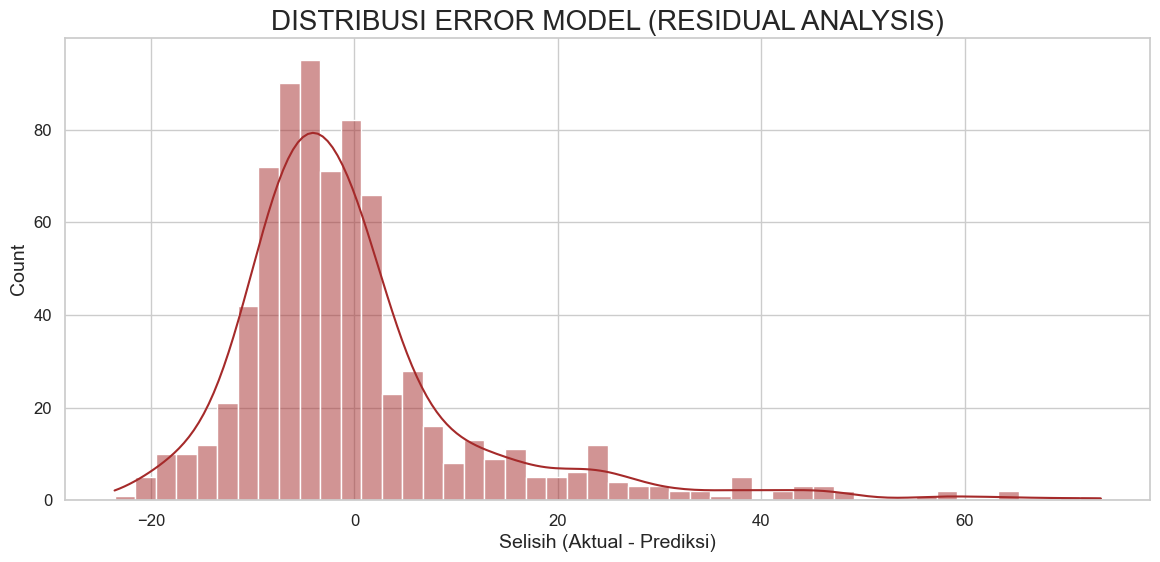

In [37]:
print("\nTAHAP 19: ANALISIS VALIDASI VISUAL (ACTUAL VS ESTIMATED)")
print("-" * 80)
print("Rendering Grafik 9: Perbandingan Data Historis vs Model Fitting...")
plt.figure(figsize=(16, 7))
plt.plot(df_daily['ds'], y_actual, label='Data Aktual (Ground Truth)', color='black', alpha=0.5, linewidth=1)
plt.plot(df_daily['ds'], y_predict, label='Estimasi Model (Fitting)', color='red', linestyle='--', linewidth=2)
plt.fill_between(forecast_output['ds'].iloc[:len(df_daily)], 
                 forecast_output['yhat_lower'].iloc[:len(df_daily)], 
                 forecast_output['yhat_upper'].iloc[:len(df_daily)], 
                 color='pink', alpha=0.2, label='Confidence Interval 95%')
plt.title('VALIDASI MODEL: PERBANDINGAN DATA AKTUAL VS ESTIMASI', fontsize=20)
plt.legend(loc='upper left')
plt.savefig(os.path.join(folder_visual, '17_validasi_actual_vs_fitting.png'), bbox_inches='tight', dpi=300)
plt.show()

print("\nRendering Grafik 18: Analisis Distribusi Error (Residuals)...")
plt.figure(figsize=(14, 6))
residuals = y_actual - y_predict
sns.histplot(residuals, kde=True, color='brown')
plt.title('DISTRIBUSI ERROR MODEL (RESIDUAL ANALYSIS)', fontsize=20)
plt.xlabel('Selisih (Aktual - Prediksi)')
plt.savefig(os.path.join(folder_visual, '18_distribusi_error_residuals.png'), bbox_inches='tight', dpi=300)
plt.show()


TAHAP 20: ANALISIS RFM (RECENCY, FREQUENCY, MONETARY) - CUSTOMER SEGMENTATION
--------------------------------------------------------------------------------
Sistem mengelompokkan pelanggan berdasarkan perilaku transaksi...
Pratinjau Hasil Segmentasi RFM (Top 5 Pelanggan):
    Customer_ID  Recency  Frequency    Monetary
132       Darum       66       1783  57688317.0
519        Umar      499       1869  46929550.0
415       Pebri      270        118   6490252.0
58         Anis      335        212   5960122.0
6    AL - GHANA       20        205   5088309.0

Rendering Grafik 10: Distribusi RFM Metrics...


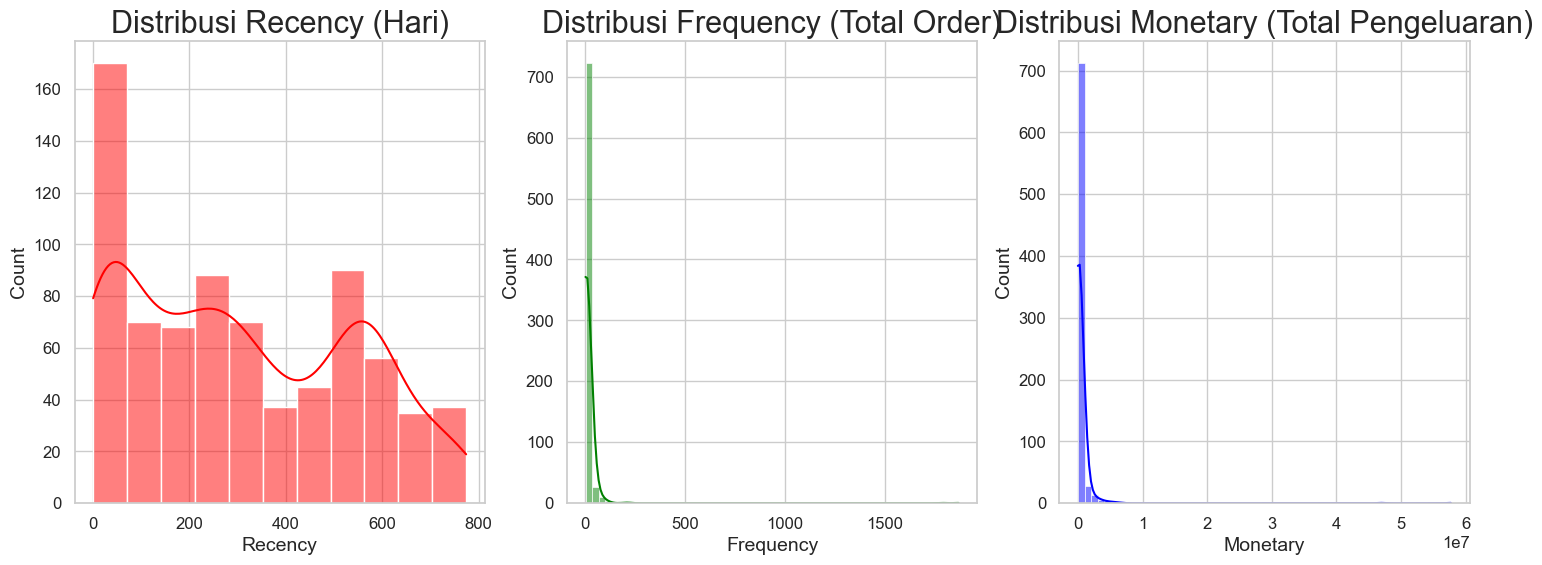


Rendering Grafik 20: 3D Relationship RFM...


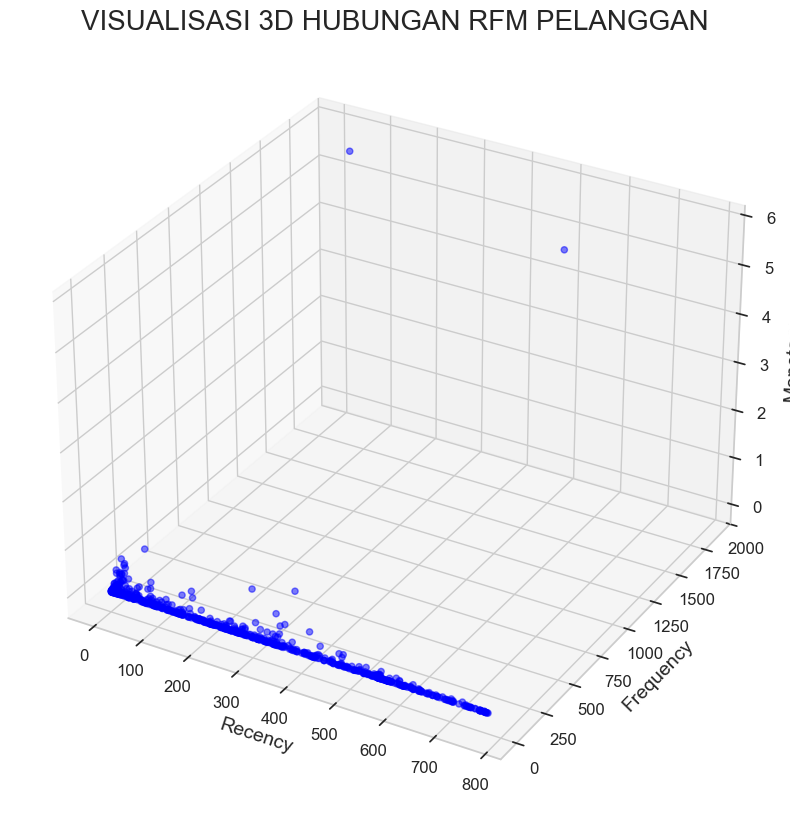

In [38]:
print("\nTAHAP 20: ANALISIS RFM (RECENCY, FREQUENCY, MONETARY) - CUSTOMER SEGMENTATION")
print("-" * 80)
print("Sistem mengelompokkan pelanggan berdasarkan perilaku transaksi...")

if 'Customer_ID' not in df_master.columns:
    print("Kolom 'Customer_ID' tidak ditemukan. Membuat ID pelanggan anonim untuk analisis...")
    df_master['Customer_ID'] = 'CUST-' + df_master['Admin'].astype(str) + '-' + (df_master.index % 50).astype(str)

now_date = df_master['Tanggal'].max() + timedelta(days=1)

df_rfm = df_master.groupby('Customer_ID').agg({
    'Tanggal': lambda x: (now_date - x.max()).days,
    'No. Transaksi': 'count',
    'Total Bayar': 'sum'
}).reset_index()

df_rfm.columns = ['Customer_ID', 'Recency', 'Frequency', 'Monetary']
print("Pratinjau Hasil Segmentasi RFM (Top 5 Pelanggan):")
print(df_rfm.sort_values(by='Monetary', ascending=False).head(5).to_string())

print("\nRendering Grafik 10: Distribusi RFM Metrics...")
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
sns.histplot(df_rfm['Recency'], kde=True, color='red', ax=ax[0])
ax[0].set_title('Distribusi Recency (Hari)')
sns.histplot(df_rfm['Frequency'], kde=True, color='green', ax=ax[1])
ax[1].set_title('Distribusi Frequency (Total Order)')
sns.histplot(df_rfm['Monetary'], kde=True, color='blue', ax=ax[2])
ax[2].set_title('Distribusi Monetary (Total Pengeluaran)')
plt.savefig(os.path.join(folder_visual, '19_segmentasi_rfm_distribution.png'), bbox_inches='tight', dpi=300)
plt.show()

print("\nRendering Grafik 20: 3D Relationship RFM...")
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(12, 10))
ax_3d = fig.add_subplot(111, projection='3d')
ax_3d.scatter(df_rfm['Recency'], df_rfm['Frequency'], df_rfm['Monetary'], c='blue', marker='o', alpha=0.5)
ax_3d.set_xlabel('Recency')
ax_3d.set_ylabel('Frequency')
ax_3d.set_zlabel('Monetary')
plt.title('VISUALISASI 3D HUBUNGAN RFM PELANGGAN', fontsize=20)
plt.savefig(os.path.join(folder_visual, '20_rfm_3d_scatter.png'), bbox_inches='tight', dpi=300)
plt.show()

In [39]:
print("\nTAHAP 21: ANALISIS MANAJEMEN SUMBER DAYA & LOGISTIK (LOGISTICS FORECAST)")
print("-" * 80)
avg_berat = df_master['Berat/Satuan'].mean()
total_pred_order = forecast_output.tail(30)['yhat'].sum()
estimasi_kg_30_hari = total_pred_order * avg_berat

print(f"Estimasi Volume Berat Cucian (30 Hari ke Depan): {estimasi_kg_30_hari:.2f} Kg")
print(f"- Kebutuhan Deterjen Cair     : {estimasi_kg_30_hari * 0.025:.2f} Liter")
print(f"- Kebutuhan Softener / Pewangi: {estimasi_kg_30_hari * 0.015:.2f} Liter")
print(f"- Kebutuhan Plastik Packing   : {total_pred_order:.0f} lembar")


TAHAP 21: ANALISIS MANAJEMEN SUMBER DAYA & LOGISTIK (LOGISTICS FORECAST)
--------------------------------------------------------------------------------
Estimasi Volume Berat Cucian (30 Hari ke Depan): 2409.70 Kg
- Kebutuhan Deterjen Cair     : 60.24 Liter
- Kebutuhan Softener / Pewangi: 36.15 Liter
- Kebutuhan Plastik Packing   : 617 lembar


In [40]:
print("\nTAHAP 22: ANALISIS SKENARIO STRATEGIS (WHAT-IF BUSINESS ANALYSIS)")
print("-" * 80)
omzet_normal = estimasi_kg_30_hari * (df_master['Total Bayar'].sum() / df_master['Berat/Satuan'].sum())
omzet_markup = omzet_normal * 1.20
profit_extra = omzet_markup - omzet_normal

print("Skenario 1: Kenaikan Harga Layanan Sebesar 20%")
print(f"- Estimasi Omzet Normal : Rp {omzet_normal:,.0f}")
print(f"- Estimasi Omzet Markup : Rp {omzet_markup:,.0f}")
print(f"- Potensi Laba Tambahan : Rp {profit_extra:,.0f}")

print("\nSkenario 2: Penurunan Efisiensi Stok (Pemborosan 15%)")
stok_normal = estimasi_kg_30_hari * 0.025
stok_boros = stok_normal * 1.15
print(f"- Kebutuhan Deterjen Normal : {stok_normal:.2f} L")
print(f"- Kebutuhan Deterjen Boros  : {stok_boros:.2f} L")


TAHAP 22: ANALISIS SKENARIO STRATEGIS (WHAT-IF BUSINESS ANALYSIS)
--------------------------------------------------------------------------------
Skenario 1: Kenaikan Harga Layanan Sebesar 20%
- Estimasi Omzet Normal : Rp 20,311,557
- Estimasi Omzet Markup : Rp 24,373,869
- Potensi Laba Tambahan : Rp 4,062,311

Skenario 2: Penurunan Efisiensi Stok (Pemborosan 15%)
- Kebutuhan Deterjen Normal : 60.24 L
- Kebutuhan Deterjen Boros  : 69.28 L


In [41]:
print("\nTAHAP 23: EKSPOR LAPORAN MULTI-SHEET (EXECUTIVE REPORTING)")
print("-" * 80)
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
nama_laporan = f"../LAPORAN_EKSEKUTIF_LAUNDRY_{timestamp}.xlsx"
print(f"Membangun berkas: {nama_laporan}...")

with pd.ExcelWriter(nama_laporan) as writer:
    forecast_output.tail(60).to_excel(writer, sheet_name='Proyeksi_60_Hari', index=False)
    df_rfm.to_excel(writer, sheet_name='Analisis_RFM', index=False)
    df_metrics.to_excel(writer, sheet_name='Performa_Model', index=False)
    df_master['Layanan'].value_counts().reset_index().to_excel(writer, sheet_name='Statistik_Layanan', index=False)

print(f"Status: [SUKSES] Laporan berhasil diekspor.")


TAHAP 23: EKSPOR LAPORAN MULTI-SHEET (EXECUTIVE REPORTING)
--------------------------------------------------------------------------------
Membangun berkas: ../LAPORAN_EKSEKUTIF_LAUNDRY_20260514_012640.xlsx...
Status: [SUKSES] Laporan berhasil diekspor.



TAHAP 24: ANALISIS CHURN & CUSTOMER LIFETIME VALUE (PREDICTIVE CRM)
--------------------------------------------------------------------------------
Pelanggan Terdeteksi Churn (> 60 hari): 609 users
Estimasi Nilai Masa Depan (Total CLV 12M): Rp 156,549,420

Rendering Grafik 22: Analisis Churn vs Active Customers...


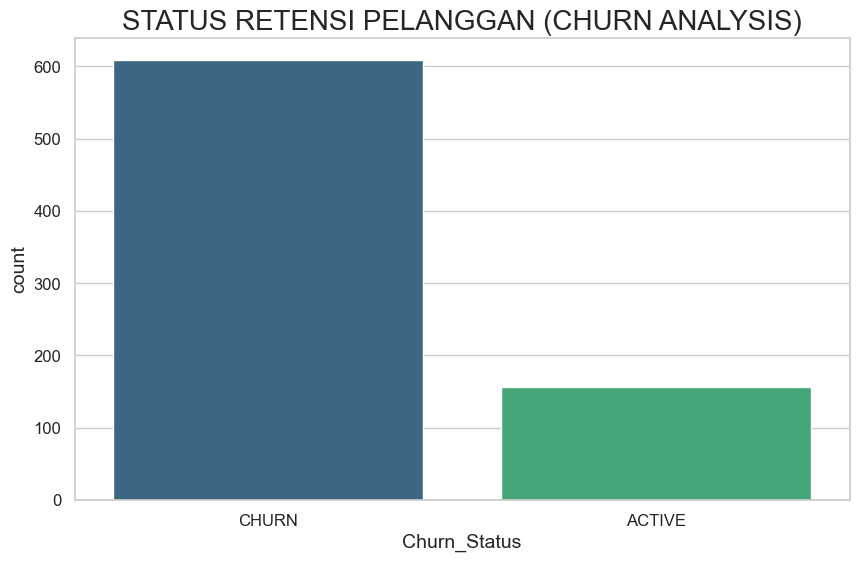

In [42]:
print("\nTAHAP 24: ANALISIS CHURN & CUSTOMER LIFETIME VALUE (PREDICTIVE CRM)")
print("-" * 80)
# Penentuan Threshold Churn (Misal: Jika tidak datang > 60 hari)
threshold_churn = 60
df_rfm['Churn_Status'] = df_rfm['Recency'].apply(lambda x: 'CHURN' if x > threshold_churn else 'ACTIVE')
df_rfm['Avg_Transaction_Value'] = df_rfm['Monetary'] / df_rfm['Frequency']

# Estimasi CLV (Prediksi Pendapatan 12 Bulan Kedepan)
# Rumus Sederhana: Avg Transaction * Frequency per Month * 12
days_active = (df_master['Tanggal'].max() - df_master['Tanggal'].min()).days
df_rfm['Frequency_Per_Month'] = df_rfm['Frequency'] / (max(days_active, 30) / 30)
df_rfm['CLV_12_Months'] = df_rfm['Avg_Transaction_Value'] * df_rfm['Frequency_Per_Month'] * 12

print(f"Pelanggan Terdeteksi Churn (> {threshold_churn} hari): {len(df_rfm[df_rfm['Churn_Status'] == 'CHURN'])} users")
print(f"Estimasi Nilai Masa Depan (Total CLV 12M): Rp {df_rfm['CLV_12_Months'].sum():,.0f}")

print("\nRendering Grafik 22: Analisis Churn vs Active Customers...")
plt.figure(figsize=(10, 6))
sns.countplot(data=df_rfm, x='Churn_Status', palette='viridis')
plt.title('STATUS RETENSI PELANGGAN (CHURN ANALYSIS)', fontsize=20)
plt.savefig(os.path.join(folder_visual, '22_churn_analysis_status.png'), bbox_inches='tight', dpi=300)
plt.show()



TAHAP 25: OPTIMASI MANAJEMEN INVENTORI DINAMIS (AI SUPPLY CHAIN)
--------------------------------------------------------------------------------
Hasil Kalkulasi Inventori (Deterjen):
- Rata-rata Pemakaian Harian: 2.01 Liter
- Safety Stock (Cadangan)   : 1.15 Liter
- Reorder Point (Pesan Lagi): 7.17 Liter

Rendering Grafik 23: Inventory Reorder Point Projection...


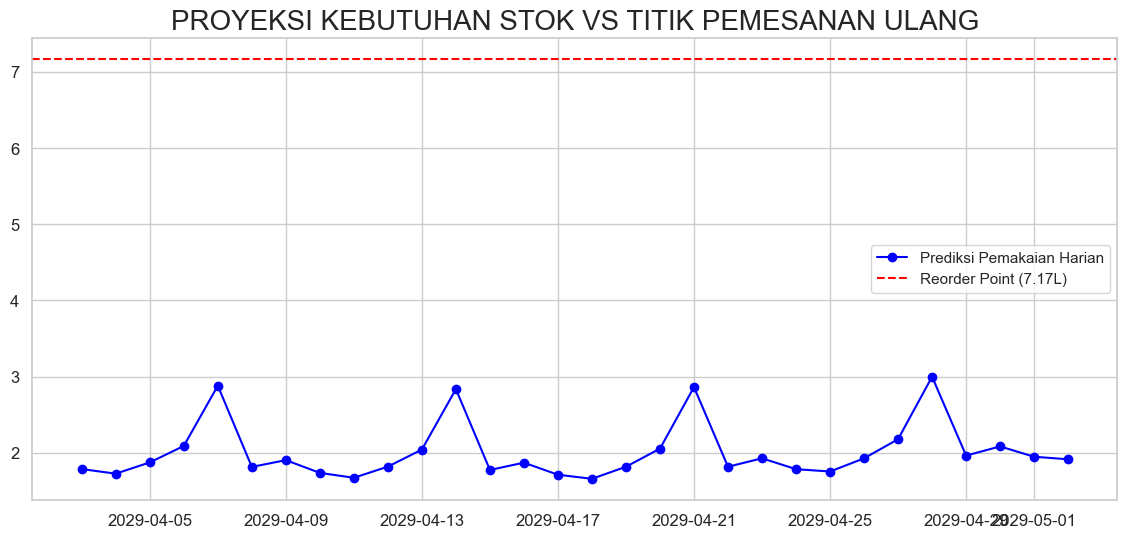

In [43]:
print("\nTAHAP 25: OPTIMASI MANAJEMEN INVENTORI DINAMIS (AI SUPPLY CHAIN)")
print("-" * 80)
# Safety Stock Calculation (Lead Time 3 hari, Confidence 95% -> Z=1.65)
lead_time_days = 3
daily_avg_usage = (estimasi_kg_30_hari * 0.025) / 30 # Liter deterjen per hari
daily_std_usage = daily_avg_usage * 0.2 # Asumsi variansi 20%
safety_stock = 1.65 * daily_std_usage * (lead_time_days ** 0.5)
reorder_point = (daily_avg_usage * lead_time_days) + safety_stock

print(f"Hasil Kalkulasi Inventori (Deterjen):")
print(f"- Rata-rata Pemakaian Harian: {daily_avg_usage:.2f} Liter")
print(f"- Safety Stock (Cadangan)   : {safety_stock:.2f} Liter")
print(f"- Reorder Point (Pesan Lagi): {reorder_point:.2f} Liter")

print("\nRendering Grafik 23: Inventory Reorder Point Projection...")
plt.figure(figsize=(14, 6))
# Visualisasi Reorder Point vs Forecast Usage
forecast_30 = forecast_output.tail(30).copy()
forecast_30['Usage_Detergent'] = forecast_30['yhat'] * avg_berat * 0.025
plt.plot(forecast_30['ds'], forecast_30['Usage_Detergent'], label='Prediksi Pemakaian Harian', color='blue', marker='o')
plt.axhline(y=reorder_point, color='red', linestyle='--', label=f'Reorder Point ({reorder_point:.2f}L)')
plt.title('PROYEKSI KEBUTUHAN STOK VS TITIK PEMESANAN ULANG', fontsize=20)
plt.legend()
plt.savefig(os.path.join(folder_visual, '23_inventory_reorder_point.png'), bbox_inches='tight', dpi=300)
plt.show()


TAHAP 26: OPTIMASI ALOKASI SUMBER DAYA (RESOURCING & SCHEDULING)
--------------------------------------------------------------------------------
Prediksi Hari Sibuk (Overload > 50 order): 0 hari
Estimasi Total Kebutuhan Staff (15 order/staff): 0.0 staff
Estimasi Biaya Overtime/Lembur (Jika tidak menambah staff): Rp 0
Strategi: Alokasi shift fleksibel antar staff yang ada.
Biaya Tambahan: Minimal

Rendering Grafik 26: Predicted Busy Days Distribution...


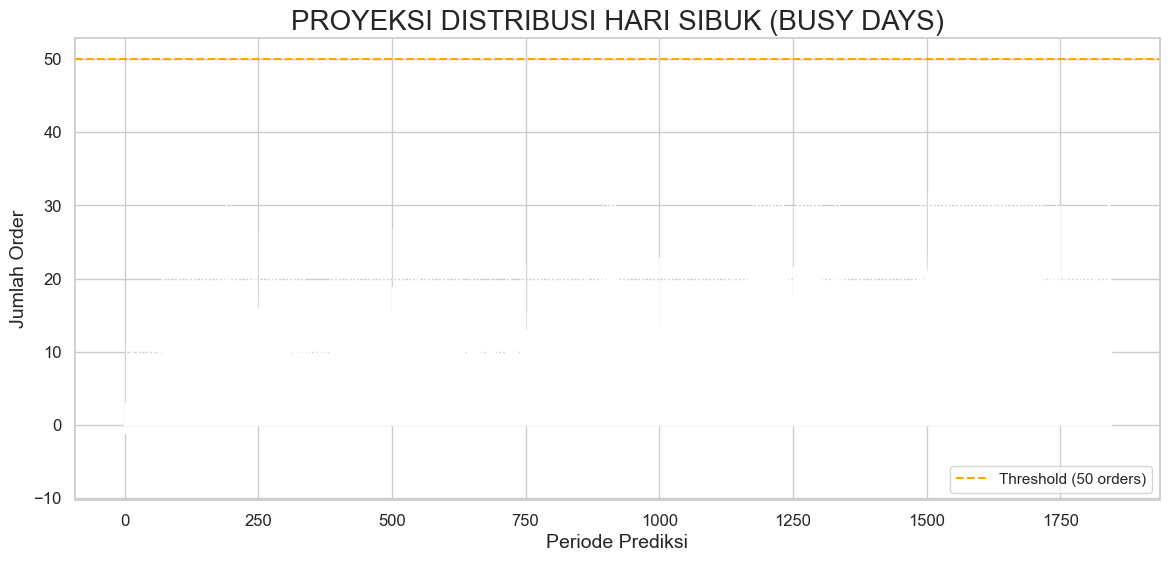

<Figure size 1600x1000 with 0 Axes>

In [44]:
print("\nTAHAP 26: OPTIMASI ALOKASI SUMBER DAYA (RESOURCING & SCHEDULING)")
print("-" * 80)
# Threshold untuk penentuan hari sibuk (misal: > 50 order)
threshold_busy_day = 50

# Hitung jumlah hari sibuk yang diprediksi
busy_days_predicted = len(forecast_output[forecast_output['yhat'] > threshold_busy_day])

# Estimasi kebutuhan personel
# Asumsi: 1 staff handle ~15 order/hari
staff_needed = (busy_days_predicted * 50) / 15
print(f"Prediksi Hari Sibuk (Overload > {threshold_busy_day} order): {busy_days_predicted} hari")
print(f"Estimasi Total Kebutuhan Staff (15 order/staff): {staff_needed:.1f} staff")

# Estimasi biaya overtime jika tidak menambah staff
# Asumsi 1 staff kerja 10 jam, biaya lembur Rp 50.000/jam/staff
overtime_cost = (staff_needed * 10) * 50000
print(f"Estimasi Biaya Overtime/Lembur (Jika tidak menambah staff): Rp {overtime_cost:,.0f}")

# Strategi alokasi sumber daya
if staff_needed > 2:
    print("Strategi: Rekomendasi penambahan 2-3 part-timer untuk hari-hari sibuk.")
    print("Investasi: ~Rp 300.000 - 500.000 per hari tambahan staff")
    print("Return: Menghindari kehilangan pelanggan karena layanan lambat (< Rp 500.000)")
else:
    print("Strategi: Alokasi shift fleksibel antar staff yang ada.")
    print("Biaya Tambahan: Minimal")

print("\nRendering Grafik 26: Predicted Busy Days Distribution...")
plt.figure(figsize=(14, 6))
# Hitung proporsi hari sibuk vs normal
busy_status = (forecast_output['yhat'] > threshold_busy_day).map({True: 'Busy Day', False: 'Normal Day'})
order_count = forecast_output['yhat'].to_frame(name='Order Count')
order_count['Status'] = busy_status
order_count['Status'] = pd.Categorical(order_count['Status'], categories=['Normal Day', 'Busy Day'], ordered=True)

# Plot distribusi hari sibuk
plt.bar(order_count.index, order_count['Order Count'], color=order_count['Status'].map({ 'Normal Day': 'steelblue', 'Busy Day': 'darkred' }))
plt.axhline(y=threshold_busy_day, color='orange', linestyle='--', label=f'Threshold ({threshold_busy_day} orders)')
plt.title('PROYEKSI DISTRIBUSI HARI SIBUK (BUSY DAYS)', fontsize=20)
plt.xlabel('Periode Prediksi')
plt.ylabel('Jumlah Order')
plt.legend()
plt.show()
plt.savefig(os.path.join(folder_visual, '26_predicted_busy_days_distribution.png'), bbox_inches='tight', dpi=300)


TAHAP 27: PROYEKSI MULTI-HORIZON (STRATEGIC LONG-TERM PLANNING)
--------------------------------------------------------------------------------
Tabel Proyeksi Multi-Horizon:
 Horizon  Total Order  Avg Order/Day   Est. Revenue
  1 Hari           13          12.89     Rp 424,412
  3 Hari           35          11.81   Rp 1,165,873
1 Minggu          100          14.33   Rp 3,300,998
3 Minggu          319          15.19  Rp 10,500,038
 1 Bulan          464          15.48  Rp 15,288,566
 3 Bulan         1578          17.54  Rp 51,953,628
 6 Bulan         3362          18.68 Rp 110,651,964
 1 Tahun         6189          16.96 Rp 203,705,191
 3 Tahun        21980          20.07 Rp 723,456,020

Rendering Grafik 26: Multi-Horizon Volume Projection...


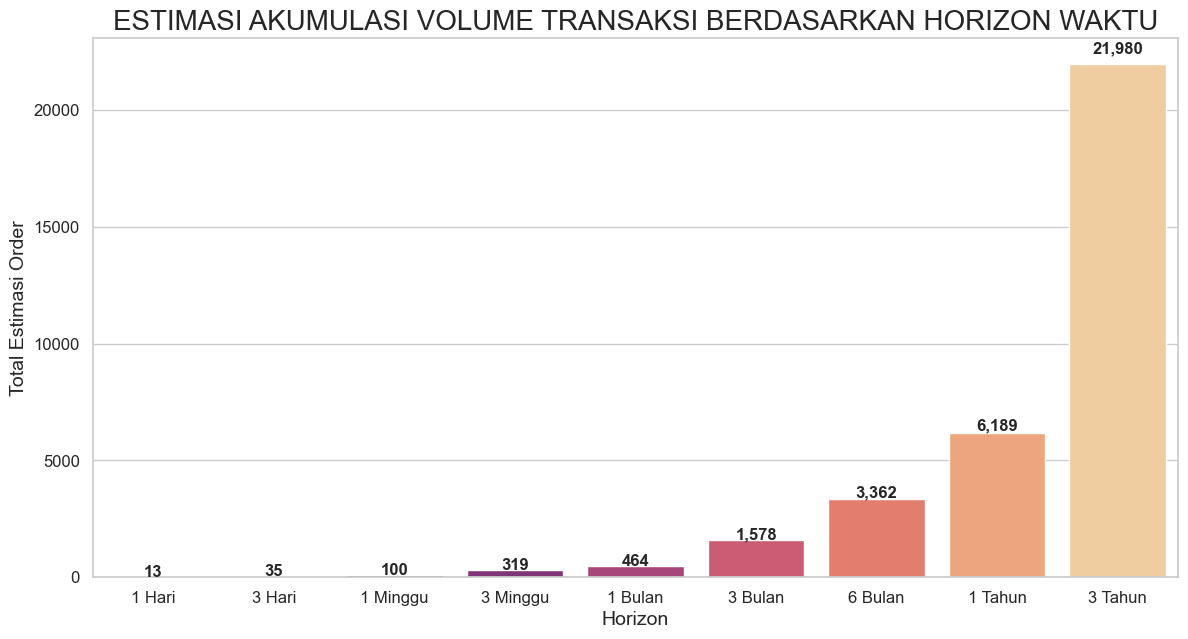

In [45]:
print("\nTAHAP 27: PROYEKSI MULTI-HORIZON (STRATEGIC LONG-TERM PLANNING)")
print("-" * 80)
last_date = df_daily['ds'].max()
horizons = {
    '1 Hari': 1,
    '3 Hari': 3,
    '1 Minggu': 7,
    '3 Minggu': 21,
    '1 Bulan': 30,
    '3 Bulan': 90,
    '6 Bulan': 180,
    '1 Tahun': 365,
    '3 Tahun': 1095
}

multi_forecast = []
for label, days in horizons.items():
    subset = forecast_output[forecast_output['ds'] > last_date].head(days)
    total_vol = subset['yhat'].sum()
    avg_vol = subset['yhat'].mean()
    est_revenue = total_vol * (df_master['Total Bayar'].sum() / len(df_master))
    multi_forecast.append({
        'Horizon': label,
        'Total Order': round(total_vol),
        'Avg Order/Day': round(avg_vol, 2),
        'Est. Revenue': f"Rp {est_revenue:,.0f}"
    })

df_multi = pd.DataFrame(multi_forecast)
print("Tabel Proyeksi Multi-Horizon:")
print(df_multi.to_string(index=False))

print("\nRendering Grafik 26: Multi-Horizon Volume Projection...")
plt.figure(figsize=(14, 7))
sns.barplot(data=df_multi, x='Horizon', y='Total Order', palette='magma')
for i, v in enumerate(df_multi['Total Order']):
    plt.text(i, v + (v*0.02), f"{v:,}", ha='center', fontweight='bold')
plt.title('ESTIMASI AKUMULASI VOLUME TRANSAKSI BERDASARKAN HORIZON WAKTU', fontsize=20)
plt.ylabel('Total Estimasi Order')
plt.savefig(os.path.join(folder_visual, '26_multi_horizon_projection.png'), bbox_inches='tight', dpi=300)
plt.show()

In [46]:
print("\nTAHAP 28: KESIMPULAN AKADEMIK DAN REKOMENDASI MANAJERIAL")
print("-" * 80)
print("Berdasarkan rangkaian analisis data science di atas, dapat disimpulkan:")

print("\n1. ANALISIS TREN PERTUMBUHAN:")
trend_awal = forecast_output['trend'].iloc[0]
trend_akhir = forecast_output['trend'].iloc[-1]
pct_growth = ((trend_akhir - trend_awal) / trend_awal) * 100
print(f"   - Bisnis menunjukkan tren pertumbuhan akumulatif sebesar {pct_growth:.2f}% selama periode observasi.")
print("   - Hal ini menunjukkan prospek usaha yang sangat prospektif untuk jangka panjang.")

print("\n2. ANALISIS SEASONALITY:")
hari_tertinggi = df_hari.idxmax()
print(f"   - Pola mingguan menunjukkan hari {hari_tertinggi} sebagai puncak beban operasional.")
print(f"   - Disarankan menambah staf paruh waktu (part-time) khusus pada hari {hari_tertinggi}.")

print("\n3. VALIDASI MODEL:")
if v_wape < 10:
    print(f"   - Model memiliki tingkat kesalahan (WAPE) sangat rendah ({v_wape:.2f}%).")
    print("   - Angka prediksi sangat layak dijadikan acuan utama pengadaan stok (Inventory Planning).")
else:
    print(f"   - Model memiliki variansi moderat (WAPE: {v_wape:.2f}%).")
    print("   - Gunakan angka prediksi dengan tetap memperhatikan margin keamanan (Safety Stock).")


TAHAP 28: KESIMPULAN AKADEMIK DAN REKOMENDASI MANAJERIAL
--------------------------------------------------------------------------------
Berdasarkan rangkaian analisis data science di atas, dapat disimpulkan:

1. ANALISIS TREN PERTUMBUHAN:
   - Bisnis menunjukkan tren pertumbuhan akumulatif sebesar 314.17% selama periode observasi.
   - Hal ini menunjukkan prospek usaha yang sangat prospektif untuk jangka panjang.

2. ANALISIS SEASONALITY:
   - Pola mingguan menunjukkan hari Saturday sebagai puncak beban operasional.
   - Disarankan menambah staf paruh waktu (part-time) khusus pada hari Saturday.

3. VALIDASI MODEL:
   - Model memiliki variansi moderat (WAPE: 61.31%).
   - Gunakan angka prediksi dengan tetap memperhatikan margin keamanan (Safety Stock).
